## Covariance “sky plate” visualization

This notebook visualizes the predicted on-sky covariance at three example epochs and compares the *physical* selection shapes used by the three healpixel-selection strategies:

- **disc**: conservative circle bound from major-axis sigma (`covariance`)
- **mc**: sampled variants from sky covariance (`covariance_mc`)
- **polygon**: explicit N-sigma ellipse boundary polygon (`covariance_polygon`)

All plots are in a local tangent-plane basis:

- \(x = \Delta\mathrm{RA} \cos(\mathrm{Dec}_0)\) (degrees)
- \(y = \Delta\mathrm{Dec}\) (degrees)

where (RA0, Dec0) is the nominal prediction at that epoch.

In [25]:
import os
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import quivr as qv
import pyarrow as pa
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

from adam_assist import ASSISTPropagator
from adam_core.orbits import Orbits
from adam_core.orbits.query.sbdb import query_sbdb
from adam_core.observers import Observers
from adam_core.coordinates.covariances import CoordinateCovariances
from adam_core.dynamics.propagation import propagate_2body
from adam_core.dynamics.ephemeris import generate_ephemeris_2body

# Make matplotlib deterministic-ish and avoid writing to ~/.matplotlib
os.environ.setdefault("MPLCONFIGDIR", "/tmp/mpl-cache")

plt.rcParams["figure.dpi"] = 120
np.set_printoptions(precision=4, suppress=True)

In [26]:
# Load a sample orbit with covariance from the test data
orbits = Orbits.from_parquet("../tests/data/sample_orbits.parquet")

# Pick 5 "real" orbits from the sample file to compare.
# These indices come from the earlier list of candidates (higher velocity sigma / more interesting).
orbits = orbits.take([20, 0, 22, 24, 14])

# Optional: add a real object from SBDB (requires astroquery cache write access)
try:
    _2025_MR4 = query_sbdb(["2025 MR4"])
    _2025_MR4 = _2025_MR4.set_column(
        "object_id", pa.array(["2025 MR4"], type=pa.large_string())
    )
    orbits = qv.concatenate([orbits, _2025_MR4])
except Exception as e:
    print("(SBDB query skipped)", repr(e))


primary_object_id = "202930 Ivezic (1998 SG172)"

primary_object = orbits.select("object_id", primary_object_id)

try:
    cov0_km = primary_object.coordinates.covariance_km()  # returns (N,6,6)
    diag = np.diag(cov0_km[0])
    pos_sig_km = np.sqrt(np.maximum(diag[:3], 0.0))
    vel_sig_km_per_day = np.sqrt(np.maximum(diag[3:], 0.0))
    print("Sample primary start 1σ position (km):", pos_sig_km)
    print("Sample primary start 1σ velocity (km/day):", vel_sig_km_per_day)
except Exception as e:
    print("(covariance_km sanity skipped)", repr(e))

# Pick an observatory code used in the tests
obscode = "I41"

# Shared time offsets (days) for all objects.
# You can also set a per-object start_offset_days if you want.
start_offset_days = 0.0

# Propagation strategy consistent with precovery:
# 1) ASSIST to mean epoch (with covariance)
# 2) 2-body to each epoch
# 3) generate topocentric ephemeris (with covariance)
prop = ASSISTPropagator()

cases = []
for orb in orbits:

    orbit_epoch_mjd = float(orb.coordinates.time.mjd().to_numpy(zero_copy_only=False)[0])
    mjd_start = orbit_epoch_mjd + float(start_offset_days)
    mjds_i = np.array(
        [mjd_start, mjd_start + 30.0, mjd_start + 365.0, mjd_start + 5.0 * 365.0],
        dtype=float,
    )
    times_i = orb.coordinates.time.from_mjd(mjds_i, scale="utc")

    # Precovery-consistent strategy: ASSIST to mean epoch, then 2-body to each requested time
    mean_time = orb.coordinates.time.from_mjd([float(mjds_i.mean())], scale="utc")
    mean_orbit = prop.propagate_orbits(orb, mean_time, covariance=True)
    propagated = propagate_2body(mean_orbit, times_i)

    observers = Observers.from_code(obscode, times_i)
    eph_i = generate_ephemeris_2body(propagated, observers)

    assert eph_i.coordinates.covariance is not None and not eph_i.coordinates.covariance.is_all_nan()

    cases.append(
        {
            "orbit": orb,
            "mjds": mjds_i,
            "eph": eph_i,
            "cov6": eph_i.coordinates.covariance.to_matrix(),
            "lon": eph_i.coordinates.lon.to_numpy(zero_copy_only=False).astype(float),
            "lat": eph_i.coordinates.lat.to_numpy(zero_copy_only=False).astype(float),
        }
    )

primary_case = next(c for c in cases if c["orbit"].object_id[0].as_py() == primary_object_id)

orbit = primary_case["orbit"]
mjds = primary_case["mjds"]
times = orbit.coordinates.time.from_mjd(mjds, scale="utc")
eph = primary_case["eph"]

assert eph.coordinates.covariance is not None and not eph.coordinates.covariance.is_all_nan()
print("Ephemeris rows:", len(eph))
print(
    "Epochs: MJD",
    mjds[0],
    f"(initial), {mjds[1]} (+1 month), {mjds[2]} (+1 year), {mjds[3]} (+5 years)",
)
print("Primary case:", "object_id:", orbit.object_id[0].as_py())
print("Example RA/Dec:", eph.coordinates.lon[0].as_py(), eph.coordinates.lat[0].as_py())

# Summarize the *sky-plane* covariance you are actually visualizing (tangent-plane major/minor)
cov6 = eph.coordinates.covariance.to_matrix()
lon = eph.coordinates.lon.to_numpy(zero_copy_only=False).astype(float)
lat = eph.coordinates.lat.to_numpy(zero_copy_only=False).astype(float)
for i in range(len(eph)):
    cov_ll = cov6[i, 1:3, 1:3]
    cos_lat = float(np.cos(np.deg2rad(lat[i])))
    A = np.array([[cos_lat, 0.0], [0.0, 1.0]], dtype=float)
    cov_xy = A @ cov_ll @ A.T
    w, _ = np.linalg.eigh(0.5 * (cov_xy + cov_xy.T))
    w = np.maximum(w, 0.0)
    sig_minor = float(np.sqrt(w[0]))
    sig_major = float(np.sqrt(w[1]))
    print(
        f"  MJD {mjds[i]:.1f}: 3σ major={3*sig_major:.4f}° ({3*sig_major*3600:.1f}\"), "
        f"3σ minor={3*sig_minor:.4f}° ({3*sig_minor*3600:.1f}\")"
    )

Sample primary start 1σ position (km): [41.5055 31.7551 39.6031]
Sample primary start 1σ velocity (km/day): [0. 0. 0.]
Ephemeris rows: 4
Epochs: MJD 58190.0 (initial), 58220.0 (+1 month), 58555.0 (+1 year), 60015.0 (+5 years)
Primary case: object_id: 202930 Ivezic (1998 SG172)
Example RA/Dec: 115.47665697655039 24.881199799619885
  MJD 58190.0: 3σ major=0.0000° (0.1"), 3σ minor=0.0000° (0.1")
  MJD 58220.0: 3σ major=0.0000° (0.1"), 3σ minor=0.0000° (0.1")
  MJD 58555.0: 3σ major=0.0000° (0.1"), 3σ minor=0.0000° (0.1")
  MJD 60015.0: 3σ major=0.0000° (0.1"), 3σ minor=0.0000° (0.1")


/Users/kathleenkiker/precovery_project/precovery/.venv/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 1 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/Users/kathleenkiker/precovery_project/precovery/.venv/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "taiutc" yielded 1 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/Users/kathleenkiker/precovery_project/precovery/.venv/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 1 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/Users/kathleenkiker/precovery_project/precovery/.venv/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "taiutc" yielded 1 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


In [27]:
def wrap_dlon_deg(lon_deg, lon0_deg):
    """Wrap (lon - lon0) into [-180, 180) degrees."""
    return (lon_deg - lon0_deg + 180.0) % 360.0 - 180.0


def cov_lonlat_to_tangent_xy(cov_ll_deg2, lat0_deg):
    """Map 2x2 covariance in (lon, lat) to tangent-plane (x=dlon*cos(lat0), y=dlat)."""
    c = float(np.cos(np.deg2rad(lat0_deg)))
    A = np.array([[c, 0.0], [0.0, 1.0]], dtype=float)
    return A @ cov_ll_deg2 @ A.T


def ellipse_boundary_from_cov(cov_xy_deg2, n_sigma=3.0, num=128):
    """Return points on the N-sigma ellipse in the tangent plane."""
    cov = 0.5 * (cov_xy_deg2 + cov_xy_deg2.T)
    w, v = np.linalg.eigh(cov)
    w = np.maximum(w, 0.0)
    # sqrt(cov) = V sqrt(W) V^T
    S = v @ np.diag(np.sqrt(w)) @ v.T
    t = np.linspace(0.0, 2.0 * np.pi, int(num), endpoint=True)
    unit = np.stack([np.cos(t), np.sin(t)], axis=1)
    pts = (unit @ S.T) * float(n_sigma)
    return pts  # (num, 2)


def disc_pixels(lon0, lat0, cov_ll_deg2, nside, n_sigma=3.0):
    """Fast disc bound (major-axis sigma) -> healpix pixels.

    This is the *covariance-only* circle (no pixel-margin).

    Returns
    -------
    pix_set : set[int]
        Healpixels intersecting the covariance-only disc.
    r_cov_rad : float
        N-sigma radius in radians.
    """
    cov_xy = cov_lonlat_to_tangent_xy(cov_ll_deg2, lat0)
    w = np.linalg.eigvalsh(0.5 * (cov_xy + cov_xy.T))
    lam_max = float(np.max(np.maximum(w, 0.0)))
    sigma_major_deg = float(np.sqrt(lam_max))

    r_cov_rad = float(np.deg2rad(float(n_sigma) * sigma_major_deg))
    if not np.isfinite(r_cov_rad) or r_cov_rad <= 0.0:
        center_pix = int(hp.ang2pix(nside, lon0, lat0, lonlat=True, nest=True))
        return {center_pix}, 0.0

    # Defensive clamp: healpy routines can behave badly for r > pi
    r_cov_rad = float(min(r_cov_rad, np.pi))

    vec = hp.ang2vec(lon0, lat0, lonlat=True)
    pix = hp.query_disc(nside, vec, float(r_cov_rad), inclusive=True, nest=True)
    pix_set = set(int(p) for p in np.asarray(pix).ravel().tolist())

    # NO neighbors added
    return pix_set, r_cov_rad


def capsule_pixels(
    lon0,
    lat0,
    cov_ll_deg2,
    nside,
    n_sigma=3.0,
    max_centers: int = 64,
):
    """Fast ellipse-like approximation using ONLY `healpy.query_disc`.

    We approximate the N-sigma ellipse with a *stadium/capsule*:
    a line segment of length 2a (along the major axis) buffered by radius b (minor axis).

    Implementation: union of `query_disc` calls of radius b centered along the major axis.

    Returns
    -------
    pix_set : set[int]
    a_deg : float
        N-sigma semi-major axis in tangent plane (deg)
    b_deg : float
        N-sigma semi-minor axis in tangent plane (deg)
    e_major : np.ndarray
        Unit vector (2,) giving major-axis direction in tangent plane
    """
    cov_xy = cov_lonlat_to_tangent_xy(cov_ll_deg2, lat0)
    cov_xy = 0.5 * (cov_xy + cov_xy.T)

    w, v = np.linalg.eigh(cov_xy)
    w = np.maximum(w, 0.0)

    # N-sigma semi-axes in degrees
    b_deg = float(n_sigma) * float(np.sqrt(w[0]))
    a_deg = float(n_sigma) * float(np.sqrt(w[1]))

    # If minor axis is extremely small, fall back to a single disc
    if not np.isfinite(b_deg) or b_deg <= 0:
        pix, r = disc_pixels(lon0, lat0, cov_ll_deg2, nside, n_sigma=n_sigma)
        return pix, a_deg, b_deg, np.array([1.0, 0.0], dtype=float)

    e_major = v[:, 1].astype(float)
    e_major /= max(float(np.linalg.norm(e_major)), 1e-12)

    # Number of disc centers along the major axis (spacing ~ b)
    n_centers = int(np.ceil((2.0 * a_deg) / max(b_deg, 1e-12))) + 1
    n_centers = int(np.clip(n_centers, 1, int(max_centers)))

    u = np.linspace(-a_deg, a_deg, n_centers)
    centers_xy = np.outer(u, e_major)  # (n_centers, 2)

    cos_lat = float(np.cos(np.deg2rad(lat0)))
    cos_lat = cos_lat if np.isfinite(cos_lat) and abs(cos_lat) > 1e-12 else 1e-12

    r_rad = float(np.deg2rad(b_deg))
    pix_set: set[int] = set()

    for cxy in centers_xy:
        dlon = float(cxy[0]) / cos_lat
        dlat = float(cxy[1])
        lon_c = (lon0 + dlon) % 360.0
        lat_c = float(np.clip(lat0 + dlat, -89.999999, 89.999999))
        vec = hp.ang2vec(lon_c, lat_c, lonlat=True)
        pix = hp.query_disc(nside, vec, r_rad, inclusive=True, nest=True)
        pix_set.update(int(p) for p in np.asarray(pix).ravel().tolist())

    return pix_set, a_deg, b_deg, e_major


def ellipse_pixels(lon0, lat0, cov_ll_deg2, nside, n_sigma=3.0, num_vertices=256, fact=8):
    """Ellipse-based healpixel selection using the *area* of the N-sigma covariance ellipse.

    This fixes the previous implementation which only checked pixel centers.

    Approach:
    - Build a high-resolution polygon approximation of the ellipse boundary (num_vertices points)
    - Use `healpy.query_polygon(..., inclusive=True)` to return pixels intersecting the polygon AREA

    Returns
    -------
    pix_set : set[int]
        Healpixels intersecting the ellipse area.
    sigma_major_deg, sigma_minor_deg : float
        1-sigma semi-axis lengths in the tangent plane (degrees), before multiplying by n_sigma.
    pts_xy : np.ndarray
        Ellipse boundary points in tangent plane (degrees), shape (V, 2).
    """
    cov_xy = cov_lonlat_to_tangent_xy(cov_ll_deg2, lat0)

    # Eigen-decomposition for semi-axis lengths
    w, v = np.linalg.eigh(0.5 * (cov_xy + cov_xy.T))
    w = np.maximum(w, 0.0)
    sigma_minor_deg = float(np.sqrt(w[0]))
    sigma_major_deg = float(np.sqrt(w[1]))

    # High-res ellipse boundary in tangent plane
    angles = np.linspace(0.0, 2.0 * np.pi, int(num_vertices), endpoint=False)
    unit = np.stack([np.cos(angles), np.sin(angles)], axis=1)
    S = v @ np.diag(np.sqrt(w)) @ v.T
    pts_xy = (unit @ S.T) * float(n_sigma)

    # If the ellipse is tiny relative to the pixel size, it can trip healpy's
    # "degenerate corner" handling. In that case the correct intersection is just
    # the center pixel.
    pixel_size_deg = float(np.rad2deg(hp.nside2resol(nside)))
    extent_deg = float(np.max(np.linalg.norm(pts_xy, axis=1))) if len(pts_xy) else 0.0
    if extent_deg > 0 and extent_deg < 0.05 * pixel_size_deg:
        center_pix = int(hp.ang2pix(nside, lon0, lat0, lonlat=True, nest=True))
        return {center_pix}, sigma_major_deg, sigma_minor_deg, pts_xy

    # For very large covariances the local tangent-plane approximation breaks down, and
    # `healpy.query_polygon` is more likely to segfault than to return something useful.
    # In that regime we fall back to the conservative disc selection.
    MAX_POLY_EXTENT_DEG = 60.0
    if not np.isfinite(extent_deg) or extent_deg > MAX_POLY_EXTENT_DEG:
        pix_set, _ = disc_pixels(lon0, lat0, cov_ll_deg2, nside, n_sigma=n_sigma)
        return pix_set, sigma_major_deg, sigma_minor_deg, pts_xy

    # Convert tangent-plane points to (lon, lat)
    cos_lat = float(np.cos(np.deg2rad(lat0)))
    cos_lat = cos_lat if np.isfinite(cos_lat) and abs(cos_lat) > 1e-12 else 1e-12
    dlon = pts_xy[:, 0] / cos_lat
    dlat = pts_xy[:, 1]
    lon_poly = (lon0 + dlon) % 360.0
    lat_poly = np.clip(lat0 + dlat, -89.999999, 89.999999)

    if not (np.all(np.isfinite(lon_poly)) and np.all(np.isfinite(lat_poly))):
        pix_set, _ = disc_pixels(lon0, lat0, cov_ll_deg2, nside, n_sigma=n_sigma)
        return pix_set, sigma_major_deg, sigma_minor_deg, pts_xy

    # healpy.query_polygon expects vertices of shape (N, 3)
    verts = np.asarray(hp.ang2vec(lon_poly, lat_poly, lonlat=True), dtype=float)
    # Some healpy builds may return (3, N); normalize to (N, 3)
    if verts.ndim == 2 and verts.shape[0] == 3 and verts.shape[1] != 3:
        verts = verts.T
    verts = np.ascontiguousarray(verts, dtype=float)
    if verts.ndim != 2 or verts.shape[1] != 3 or not np.all(np.isfinite(verts)):
        pix_set, _ = disc_pixels(lon0, lat0, cov_ll_deg2, nside, n_sigma=n_sigma)
        return pix_set, sigma_major_deg, sigma_minor_deg, pts_xy

    try:
        pix = hp.query_polygon(nside, verts, inclusive=True, fact=int(fact), nest=True)
        pix_set = set(int(p) for p in np.asarray(pix).ravel().tolist())
    except Exception:
        # Fallback: boundary pixels only (still a decent approximation for small regions)
        pix_v = hp.ang2pix(nside, lon_poly, lat_poly, lonlat=True, nest=True)
        pix_set = set(int(p) for p in np.asarray(pix_v).ravel().tolist())

    # NO neighbors added
    return pix_set, sigma_major_deg, sigma_minor_deg, pts_xy


def mc_pixels(lon0, lat0, cov_ll_deg2, nside, n_sigma=3.0, num_samples=256, seed=0):
    """Monte Carlo healpixel selection.

    Returns *all* healpixels that contain at least one sampled point.

    Notes:
    - Samples are drawn in the local tangent plane from the covariance (scaled by n_sigma).
    - We also include the nominal predicted point pixel.
    - NO neighbors added.
    """
    cov_xy = cov_lonlat_to_tangent_xy(cov_ll_deg2, lat0)
    cov_xy = 0.5 * (cov_xy + cov_xy.T)

    # Robust sqrt (matches spirit of precovery_db: safe factorization)
    w, v = np.linalg.eigh(cov_xy)
    w = np.maximum(w, 0.0)
    L = v @ np.diag(np.sqrt(w))

    rng = np.random.default_rng(int(seed))
    z = rng.standard_normal((int(num_samples), 2))
    dxy = (z @ L.T) * float(n_sigma)

    cos_lat = float(np.cos(np.deg2rad(lat0)))
    cos_lat = cos_lat if np.isfinite(cos_lat) and abs(cos_lat) > 1e-12 else 1e-12
    dlon = dxy[:, 0] / cos_lat
    dlat = dxy[:, 1]

    lon_s = (lon0 + dlon) % 360.0
    lat_s = np.clip(lat0 + dlat, -89.999999, 89.999999)

    # Always include the nominal predicted point
    lon_all = np.concatenate([lon_s, np.array([lon0], dtype=float)])
    lat_all = np.concatenate([lat_s, np.array([lat0], dtype=float)])

    pix = hp.ang2pix(nside, lon_all, lat_all, lonlat=True, nest=True)
    pix_set = set(int(p) for p in np.asarray(pix).ravel().tolist())

    return pix_set, dxy


def polygon_pixels(lon0, lat0, cov_ll_deg2, nside, n_sigma=3.0, num_vertices=32, fact=8):
    """Polygon method: return healpixels intersecting the polygon AREA.

    We approximate the N-sigma ellipse boundary with `num_vertices` points and call
    `healpy.query_polygon(..., inclusive=True)`.

    This returns pixels intersecting the polygon area (not just boundary).
    """
    cov_xy = cov_lonlat_to_tangent_xy(cov_ll_deg2, lat0)
    pts = ellipse_boundary_from_cov(cov_xy, n_sigma=n_sigma, num=num_vertices)

    # Tiny polygons can trigger healpy "degenerate corner"; in that case the correct
    # intersection is the center pixel.
    pixel_size_deg = float(np.rad2deg(hp.nside2resol(nside)))
    extent_deg = float(np.max(np.linalg.norm(pts, axis=1))) if len(pts) else 0.0
    if extent_deg > 0 and extent_deg < 0.05 * pixel_size_deg:
        center_pix = int(hp.ang2pix(nside, lon0, lat0, lonlat=True, nest=True))
        return {center_pix}, pts

    # Avoid passing "giant" polygons to healpy; this is both physically dubious (local
    # tangent plane) and has been observed to crash kernels in some environments.
    MAX_POLY_EXTENT_DEG = 60.0
    if not np.isfinite(extent_deg) or extent_deg > MAX_POLY_EXTENT_DEG:
        pix_set, _ = disc_pixels(lon0, lat0, cov_ll_deg2, nside, n_sigma=n_sigma)
        return pix_set, pts

    cos_lat = float(np.cos(np.deg2rad(lat0)))
    cos_lat = cos_lat if np.isfinite(cos_lat) and abs(cos_lat) > 1e-12 else 1e-12
    dlon = pts[:, 0] / cos_lat
    dlat = pts[:, 1]
    lon_poly = (lon0 + dlon) % 360.0
    lat_poly = np.clip(lat0 + dlat, -89.999999, 89.999999)

    if not (np.all(np.isfinite(lon_poly)) and np.all(np.isfinite(lat_poly))):
        pix_set, _ = disc_pixels(lon0, lat0, cov_ll_deg2, nside, n_sigma=n_sigma)
        return pix_set, pts

    verts = np.asarray(hp.ang2vec(lon_poly, lat_poly, lonlat=True), dtype=float)
    if verts.ndim == 2 and verts.shape[0] == 3 and verts.shape[1] != 3:
        verts = verts.T
    verts = np.ascontiguousarray(verts, dtype=float)
    if verts.ndim != 2 or verts.shape[1] != 3 or not np.all(np.isfinite(verts)):
        pix_set, _ = disc_pixels(lon0, lat0, cov_ll_deg2, nside, n_sigma=n_sigma)
        return pix_set, pts

    try:
        pix = hp.query_polygon(nside, verts, inclusive=True, fact=int(fact), nest=True)
        pix_set = set(int(p) for p in np.asarray(pix).ravel().tolist())
    except Exception:
        # Fallback: boundary pixels only
        pix_v = hp.ang2pix(nside, lon_poly, lat_poly, lonlat=True, nest=True)
        pix_set = set(int(p) for p in np.asarray(pix_v).ravel().tolist())

    # NO neighbors added
    return pix_set, pts


def pixel_boundaries_tangent_xy(pix, nside, lon0, lat0):
    """Return boundary vertices for a HEALPix pixel in tangent-plane coordinates."""
    b = hp.boundaries(nside, int(pix), step=1, nest=True)  # (3, Nv)
    lon_b, lat_b = hp.vec2ang(b.T, lonlat=True)
    dx = wrap_dlon_deg(lon_b, lon0) * np.cos(np.deg2rad(lat0))
    dy = (lat_b - lat0)
    return dx, dy


def plot_case(ax, lon0, lat0, cov_ll_deg2, nside=32, n_sigma=3.0, num_vertices=32, mc_samples=256, mc_seed=0):
    """Combined view: all methods on one axis."""
    cov_xy = cov_lonlat_to_tangent_xy(cov_ll_deg2, lat0)

    # Covariance ellipse (physical N-sigma boundary)
    ell = ellipse_boundary_from_cov(cov_xy, n_sigma=n_sigma, num=256)

    # Disc (covariance-only)
    disc_set, r_cov_rad = disc_pixels(lon0, lat0, cov_ll_deg2, nside, n_sigma=n_sigma)
    t = np.linspace(0, 2*np.pi, 200)
    r_cov_deg = float(np.rad2deg(r_cov_rad))

    # MC
    mc_set, mc_dxy = mc_pixels(lon0, lat0, cov_ll_deg2, nside, n_sigma=n_sigma, num_samples=mc_samples, seed=mc_seed)

    # Polygon
    poly_set, poly_pts = polygon_pixels(lon0, lat0, cov_ll_deg2, nside, n_sigma=n_sigma, num_vertices=num_vertices)

    ell_scale = float(np.max(np.abs(ell))) if ell.size else 1e-6
    lim = max(1.5 * ell_scale, 1.5 * r_cov_deg, 1e-6)

    # Only render pixels that can actually appear in view; large-cov cases can select
    # huge regions and drawing every off-screen pixel can OOM/crash kernels.
    def _pixels_in_view(pix_set: set[int]) -> list[int]:
        if not pix_set:
            return []
        pix_arr = np.fromiter(pix_set, dtype=np.int64)
        try:
            lon_c, lat_c = hp.pix2ang(nside, pix_arr, nest=True, lonlat=True)
        except TypeError:
            # Some healpy versions return (theta, phi)
            theta, phi = hp.pix2ang(nside, pix_arr, nest=True)
            lon_c = np.rad2deg(phi)
            lat_c = 90.0 - np.rad2deg(theta)

        cos0 = float(np.cos(np.deg2rad(lat0)))
        dx = wrap_dlon_deg(lon_c, lon0) * cos0
        dy = (lat_c - lat0)

        pad = 2.0 * float(np.rad2deg(hp.nside2resol(nside)))
        m = (np.abs(dx) <= (lim + pad)) & (np.abs(dy) <= (lim + pad))
        return [int(p) for p in pix_arr[m].tolist()]

    # Draw HEALPix grid with method-specific highlights
    union_all = (disc_set | mc_set | poly_set)
    union = _pixels_in_view(union_all)

    MAX_PIXELS_TO_DRAW = 6000
    skipped = False
    if len(union) > MAX_PIXELS_TO_DRAW:
        union = union[:MAX_PIXELS_TO_DRAW]
        skipped = True

    for p in union:
        dx, dy = pixel_boundaries_tangent_xy(p, nside, lon0, lat0)
        # Color-code by which method(s) selected this pixel
        in_disc = p in disc_set
        in_mc = p in mc_set
        in_poly = p in poly_set

        if in_disc and in_mc and in_poly:
            color = "#e6ffe6"  # light green - all three
            edge = "#2ca02c"
            lw = 1.2
        elif in_mc and in_poly:
            color = "#fff0e6"  # light orange - MC + polygon
            edge = "#ff7f0e"
            lw = 1.0
        elif in_disc:
            color = "#e6f2ff"  # light blue - disc only
            edge = "#1f77b4"
            lw = 0.8
        else:
            color = "0.95"
            edge = "0.7"
            lw = 0.5

        ax.fill(dx, dy, color=color, edgecolor=edge, lw=lw, zorder=0, alpha=0.7)

    # Plot elements with better visibility
    ax.plot(ell[:, 0], ell[:, 1], color="k", lw=3.0, label=f"{n_sigma}σ ellipse", zorder=5)
    ax.plot(r_cov_deg*np.cos(t), r_cov_deg*np.sin(t), color="#1f77b4", lw=2.5, ls="--", alpha=0.9, label="disc bound", zorder=4)
    ax.plot(poly_pts[:, 0], poly_pts[:, 1], color="#2ca02c", lw=2.5, label="polygon boundary", zorder=4)
    ax.scatter(mc_dxy[:, 0], mc_dxy[:, 1], s=8, alpha=0.3, color="#ff7f0e", label="MC samples", zorder=3)
    ax.scatter(
        [0.0],
        [0.0],
        color="red",
        s=25,
        marker="o",
        edgecolor="white",
        linewidths=1.2,
        label="nominal position",
        zorder=6,
    )

    if skipped:
        ax.text(
            0.02,
            0.02,
            f"(pixel render capped: {len(union_all)} selected)",
            transform=ax.transAxes,
            fontsize=9,
            ha="left",
            va="bottom",
            alpha=0.9,
        )

    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x = ΔRA cos(Dec₀) [deg]", fontsize=11)
    ax.set_ylabel("y = ΔDec [deg]", fontsize=11)
    ax.set_title(
        f"RA₀={lon0:.3f}°, Dec₀={lat0:.3f}°\nHealpixels: all={len(union_all)}, disc={len(disc_set)}, MC={len(mc_set)}, poly={len(poly_set)}",
        fontsize=10,
        fontweight="bold",
    )
    ax.grid(True, alpha=0.3, ls=":", lw=0.5)

    return disc_set, mc_set, poly_set, r_cov_deg


def plot_case_separated(
    axes_row,
    lon0,
    lat0,
    cov_ll_deg2,
    nside=32,
    n_sigma=3.0,
    num_vertices=32,
    mc_samples=256,
    mc_seed=0,
    pixels_across: int = 5,
):
    """Separated view: each method on its own axis, ZOOMED TO HEALPIXEL SCALE.

    `pixels_across` controls how many healpixel diameters span the full plot width.
    Smaller values => bigger, easier-to-see pixels.
    """
    cov_xy = cov_lonlat_to_tangent_xy(cov_ll_deg2, lat0)
    ell = ellipse_boundary_from_cov(cov_xy, n_sigma=n_sigma, num=256)

    disc_set, r_cov_rad = disc_pixels(lon0, lat0, cov_ll_deg2, nside, n_sigma=n_sigma)

    # Capsule representation is currently disabled (known-broken / misleading).
    # Keeping the code around for later debugging.
    # capsule_set, a_deg, b_deg, e_major = capsule_pixels(...)

    mc_set, mc_dxy = mc_pixels(
        lon0, lat0, cov_ll_deg2, nside, n_sigma=n_sigma, num_samples=mc_samples, seed=mc_seed
    )
    poly_set, poly_pts = polygon_pixels(
        lon0, lat0, cov_ll_deg2, nside, n_sigma=n_sigma, num_vertices=num_vertices
    )

    # True-scale inset helper for capsule boundary
    def _capsule_boundary_points(a: float, b: float, e_major: np.ndarray, num: int = 128) -> np.ndarray:
        # Stadium boundary in tangent plane: segment ±a along major axis with radius b
        if not np.isfinite(a) or not np.isfinite(b) or b <= 0:
            return np.zeros((0, 2), dtype=float)
        e = e_major / max(float(np.linalg.norm(e_major)), 1e-12)
        # orthogonal direction
        n = np.array([-e[1], e[0]], dtype=float)
        # semicircle angles
        th = np.linspace(-0.5*np.pi, 0.5*np.pi, int(num)//2, endpoint=True)
        cap1 = (a * e) + (b * (np.cos(th)[:, None] * n + np.sin(th)[:, None] * e))
        cap2 = (-a * e) + (b * (np.cos(th)[:, None] * n - np.sin(th)[:, None] * e))
        return np.vstack([cap1, cap2])

    t = np.linspace(0, 2*np.pi, 200)
    r_cov_deg = np.rad2deg(r_cov_rad)

    # Choose axis limits to show the covariance geometry clearly, while still drawing the
    # selected healpixels (even if pixels are much larger than the covariance).
    pixel_size_deg = float(np.rad2deg(hp.nside2resol(nside)))
    min_lim = 0.03 * pixel_size_deg  # show at least a small fraction of a pixel for context

    # Only draw pixels that can actually appear near the origin.
    # NOTE: when lim is tiny relative to a pixel, a selected pixel can overlap the origin even if
    # its *center* is far away, so we use a generous padding.
    def _pixels_in_view(pix_set: set[int], lim_local: float) -> list[int]:
        if not pix_set:
            return []
        pix_arr = np.fromiter(pix_set, dtype=np.int64)
        try:
            lon_c, lat_c = hp.pix2ang(nside, pix_arr, nest=True, lonlat=True)
        except TypeError:
            theta, phi = hp.pix2ang(nside, pix_arr, nest=True)
            lon_c = np.rad2deg(phi)
            lat_c = 90.0 - np.rad2deg(theta)

        cos0 = float(np.cos(np.deg2rad(lat0)))
        dx = wrap_dlon_deg(lon_c, lon0) * cos0
        dy = (lat_c - lat0)

        pad = 1.5 * pixel_size_deg
        m = (np.abs(dx) <= (lim_local + pad)) & (np.abs(dy) <= (lim_local + pad))
        return [int(p) for p in pix_arr[m].tolist()]

    # True-scale geometry overlays (no inset / no rescaling)
    circ_pts = np.stack([np.cos(t), np.sin(t)], axis=1) * float(r_cov_deg)
    ell_extent = float(np.max(np.linalg.norm(ell, axis=1))) if len(ell) else 0.0
    mc_extent = float(np.max(np.linalg.norm(mc_dxy, axis=1))) if len(mc_dxy) else 0.0
    poly_extent = float(np.max(np.linalg.norm(poly_pts, axis=1))) if len(poly_pts) else 0.0
    methods = [
        ("Disc (covariance-only)", disc_set, "#1f77b4", "disc"),
        ("Monte Carlo (pixels hit by samples)", mc_set, "#ff7f0e", "mc"),
        ("Polygon (area via query_polygon)", poly_set, "#2ca02c", "poly"),
    ]

    MAX_PIXELS_TO_DRAW = 4000

    for ax, (title, pix_set, method_color, kind) in zip(axes_row, methods):
        # Per-panel scaling (matches the previous behavior): each method panel chooses
        # its own best zoom for the covariance geometry.
        if kind == "disc":
            extent = max(float(ell_extent), float(r_cov_deg))
        elif kind == "mc":
            extent = max(float(ell_extent), float(mc_extent))
        else:  # poly
            extent = max(float(ell_extent), float(poly_extent))

        lim_local = max(1.25 * extent, float(min_lim), 1e-6)

        pix_in_view = _pixels_in_view(pix_set, lim_local)
        skipped = False
        if len(pix_in_view) > MAX_PIXELS_TO_DRAW:
            pix_in_view = pix_in_view[:MAX_PIXELS_TO_DRAW]
            skipped = True

        # Draw healpixels for this method
        for p in pix_in_view:
            dx, dy = pixel_boundaries_tangent_xy(p, nside, lon0, lat0)
            ax.fill(
                dx,
                dy,
                color=method_color,
                alpha=0.10,
                edgecolor=method_color,
                lw=1.2,
                zorder=1,
            )

        # True-scale overlays on the healpixel axis
        # Always draw the physical covariance ellipse
        if len(ell):
            ax.plot(ell[:, 0], ell[:, 1], color="k", lw=2.4, zorder=4)

        if kind == "disc":
            ax.plot(circ_pts[:, 0], circ_pts[:, 1], color=method_color, lw=2.2, ls="--", alpha=0.95, zorder=4)
        elif kind == "mc":
            ax.scatter(mc_dxy[:, 0], mc_dxy[:, 1], s=10, alpha=0.25, color=method_color, zorder=3)
        elif kind == "poly":
            if len(poly_pts):
                ax.plot(poly_pts[:, 0], poly_pts[:, 1], color=method_color, lw=2.2, zorder=4)

        # Nominal point (small dot so it doesn't obscure tiny covariances)
        ax.scatter(
            [0.0],
            [0.0],
            color="red",
            s=25,
            marker="o",
            edgecolor="white",
            linewidths=1.2,
            label="nominal",
            zorder=5,
        )

        ax.set_xlim(-lim_local, lim_local)
        ax.set_ylim(-lim_local, lim_local)
        ax.set_aspect("equal", adjustable="box")
        ax.set_xlabel("x = ΔRA cos(Dec₀) [deg]", fontsize=10)
        ax.set_ylabel("y = ΔDec [deg]", fontsize=10)
        if skipped:
            ax.set_title(f"{title}\n{len(pix_set)} healpixels (render capped)", fontsize=10, fontweight="bold")
        else:
            ax.set_title(f"{title}\n{len(pix_set)} healpixels", fontsize=10, fontweight="bold")
        ax.grid(True, alpha=0.3, ls=":", lw=0.5)

    return disc_set, mc_set, poly_set, r_cov_deg

MULTI-OBJECT COVARIANCE COMPARISON (tangent-plane 3σ ellipses)


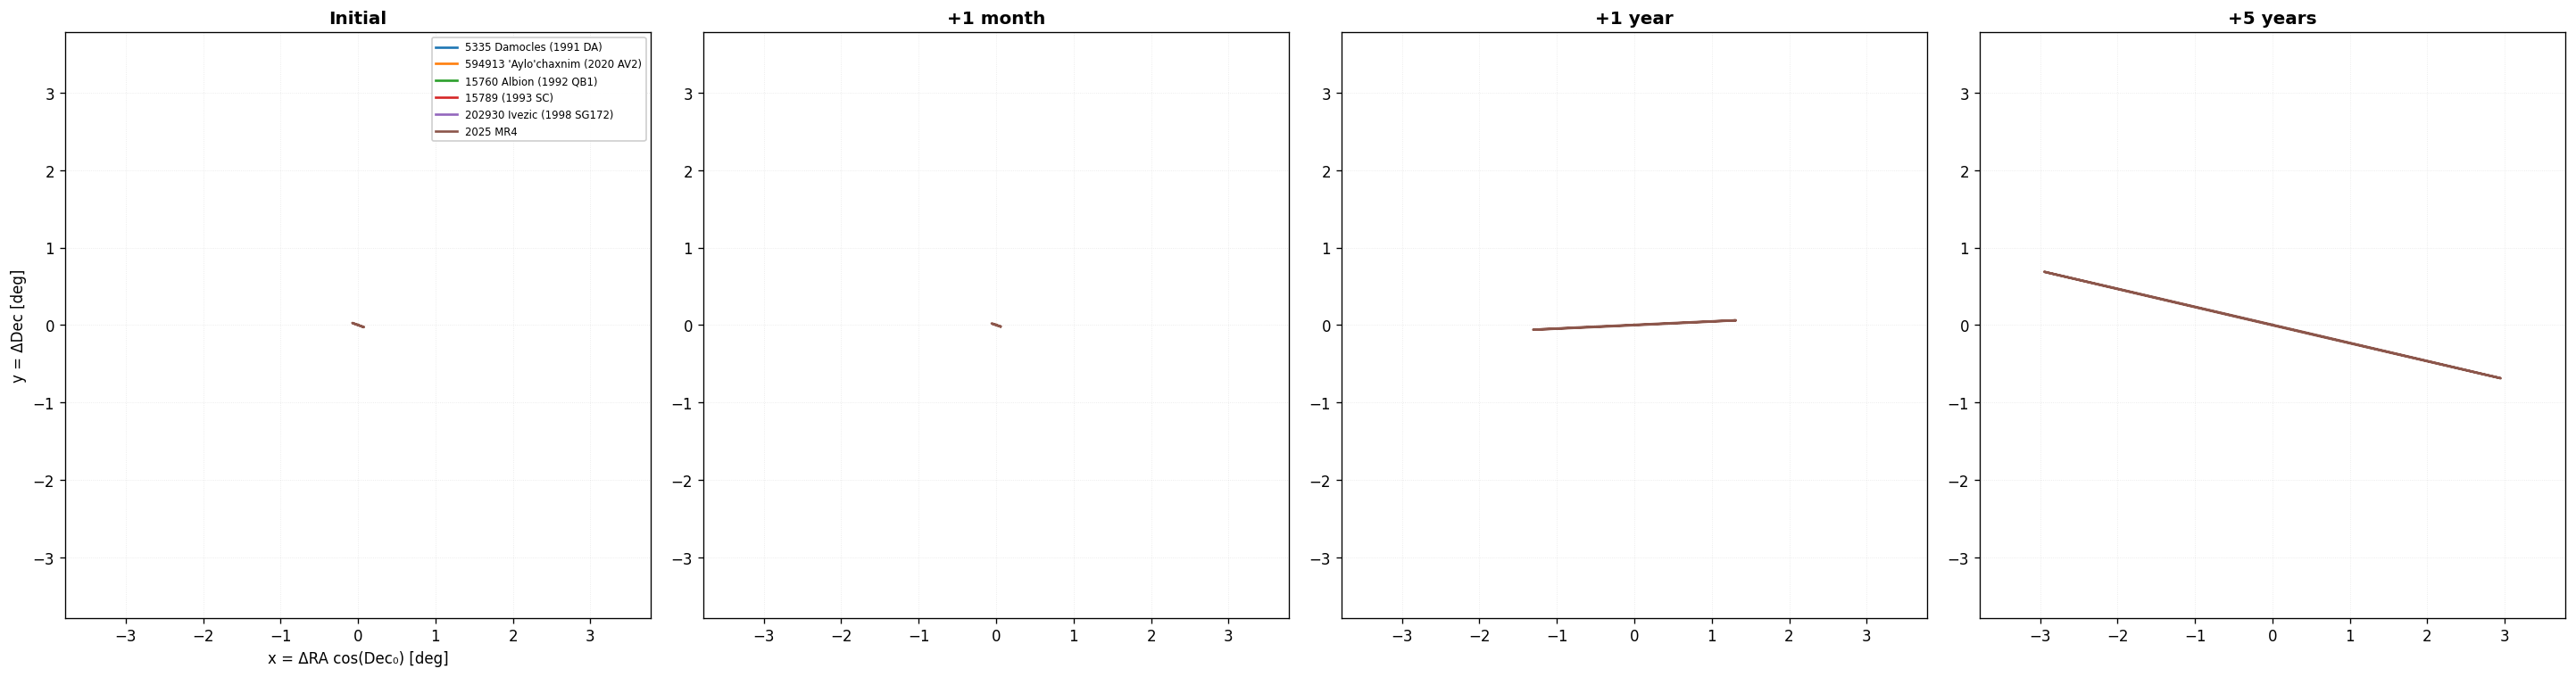

HEALPIXEL SCALE VIEW: Showing which healpixels are selected
HEALPix nside=512 → pixel diameter ≈ 0.2392°

Objects plotted: 6

--------------------------------------------------------------------------------
Object 1/6: 5335 Damocles (1991 DA)
mjd, #pix(disc), #pix(mc), #pix(polygon), r_cov(deg)
48587.000      2      1      1   6.968e-04
48617.000      1      1      1   5.918e-04
48952.000      3      1      1   7.663e-04
50412.000      1      1      1   4.379e-03


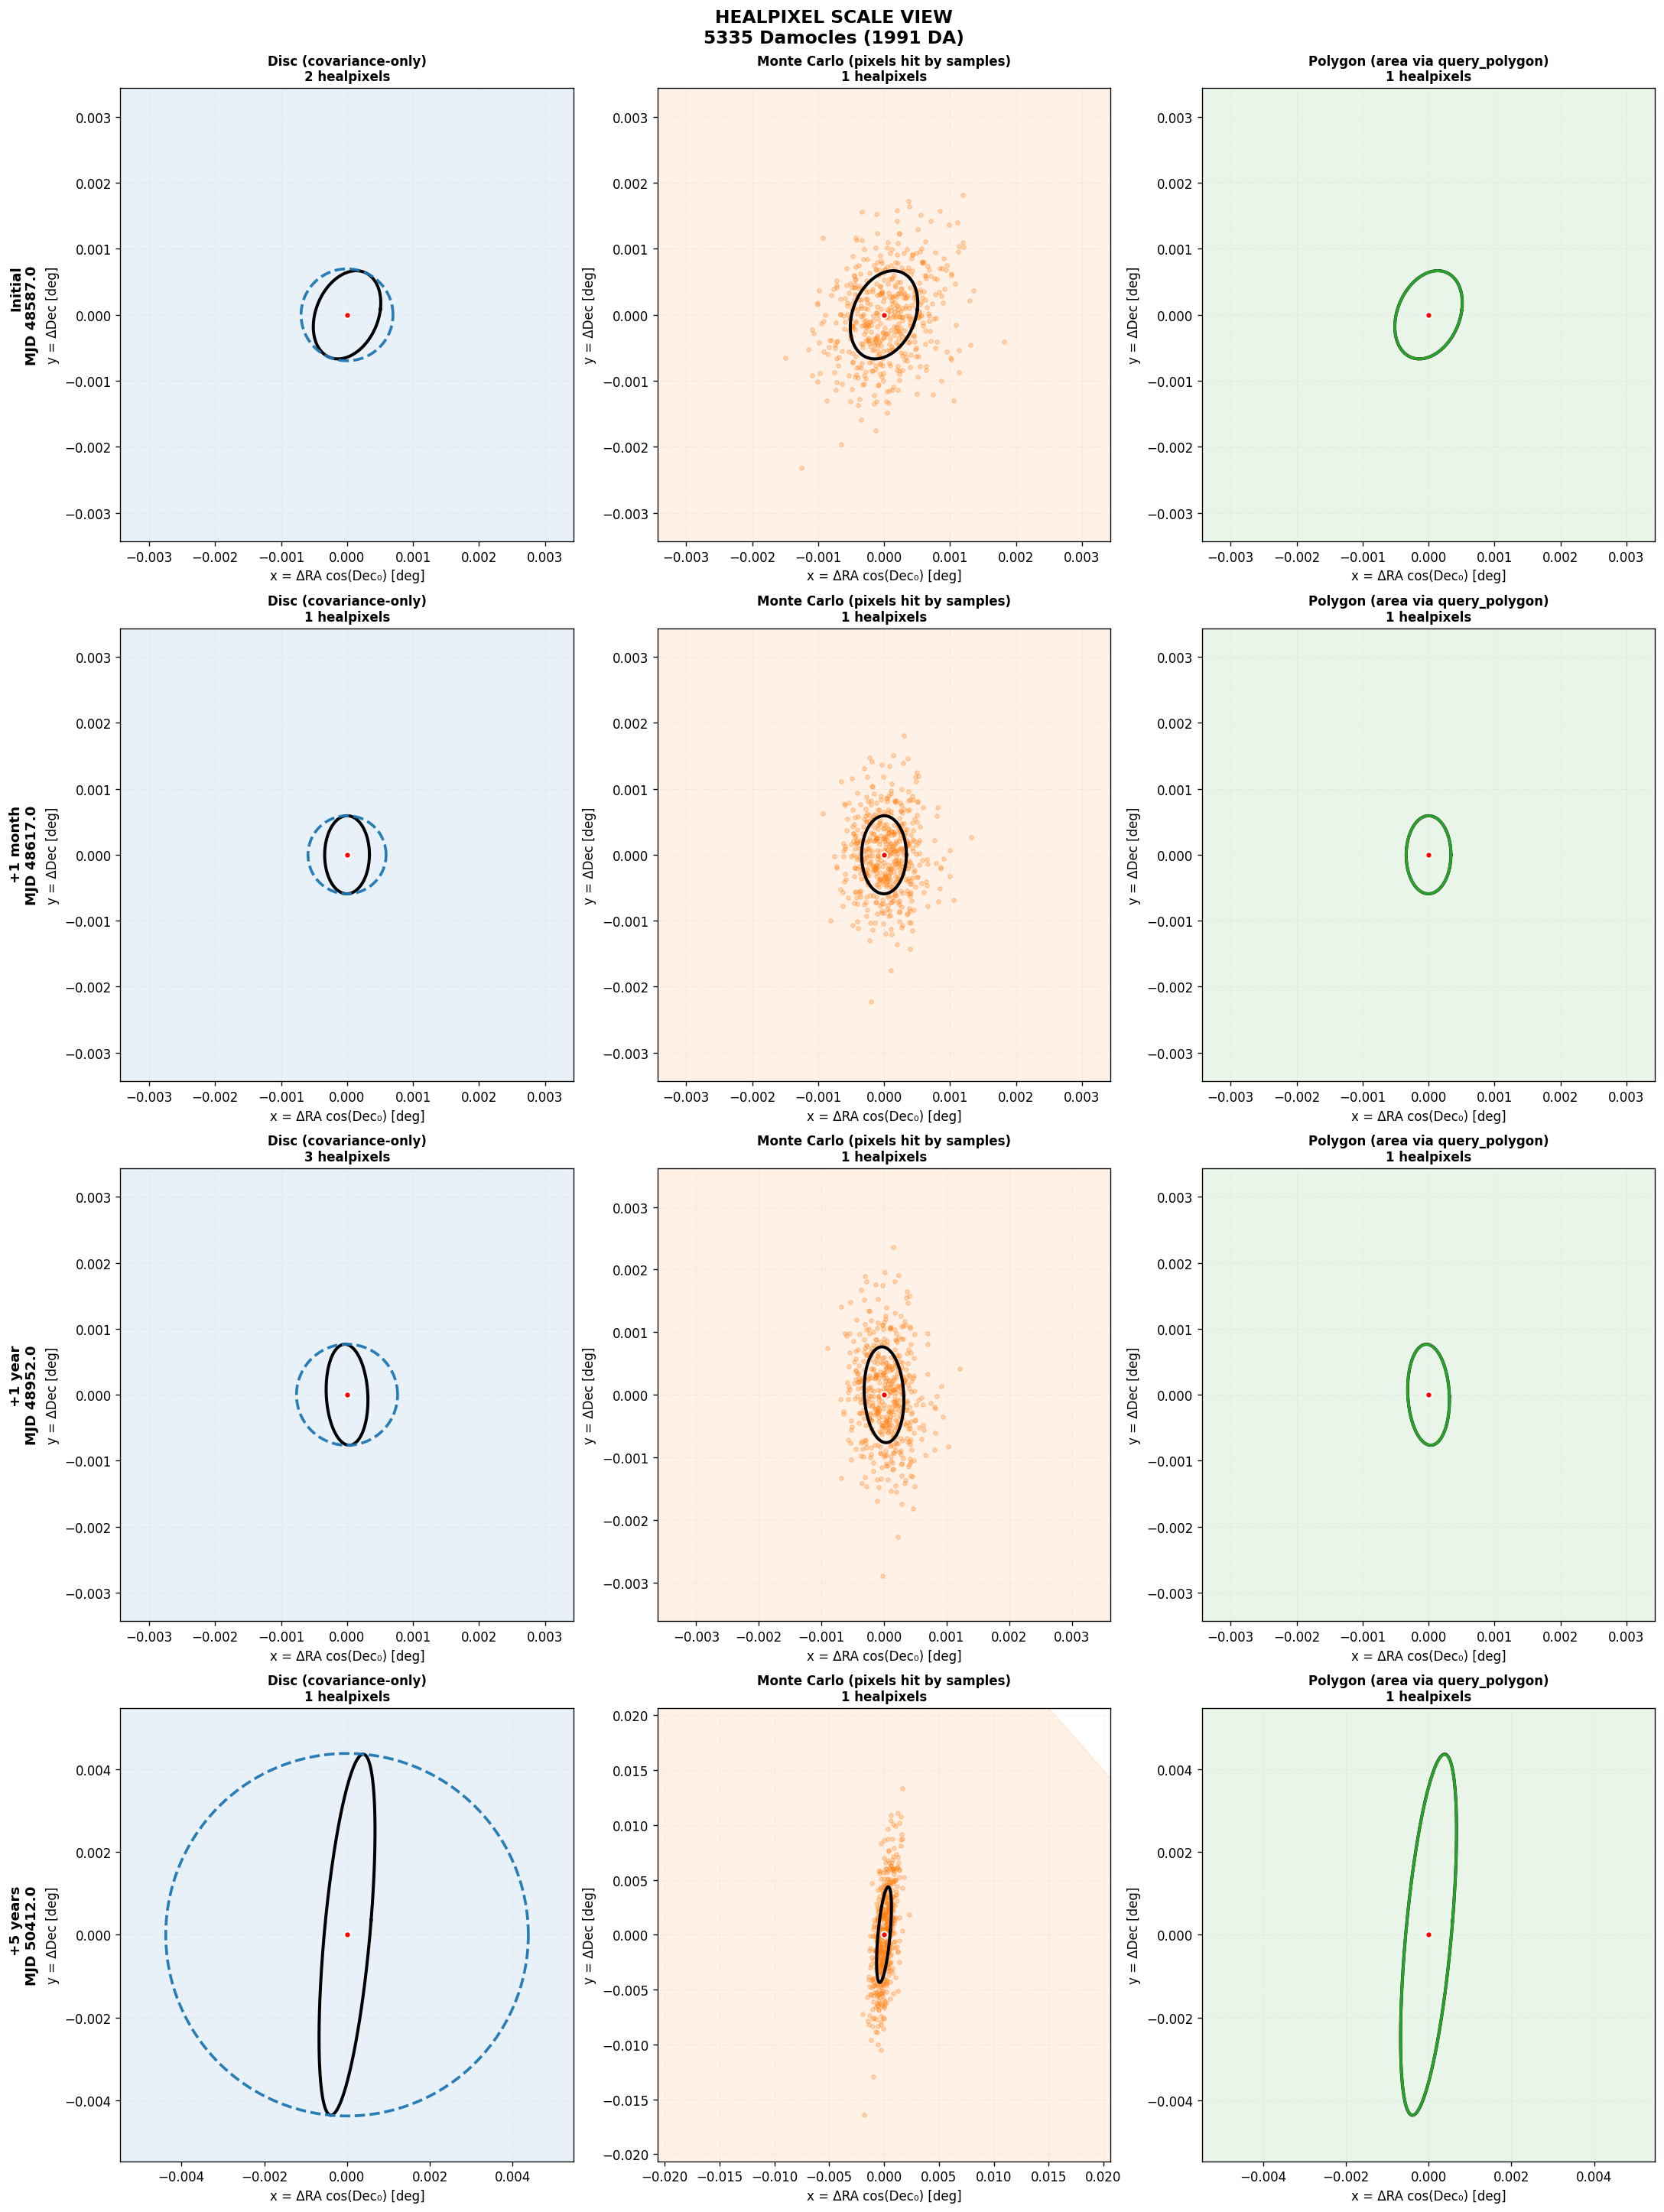


--------------------------------------------------------------------------------
Object 2/6: 594913 'Aylo'chaxnim (2020 AV2)
mjd, #pix(disc), #pix(mc), #pix(polygon), r_cov(deg)
59091.000      1      1      1   1.998e-04
59121.000      1      1      1   4.993e-04
59456.000      1      1      1   1.185e-04
60916.000      2      1      1   1.440e-03


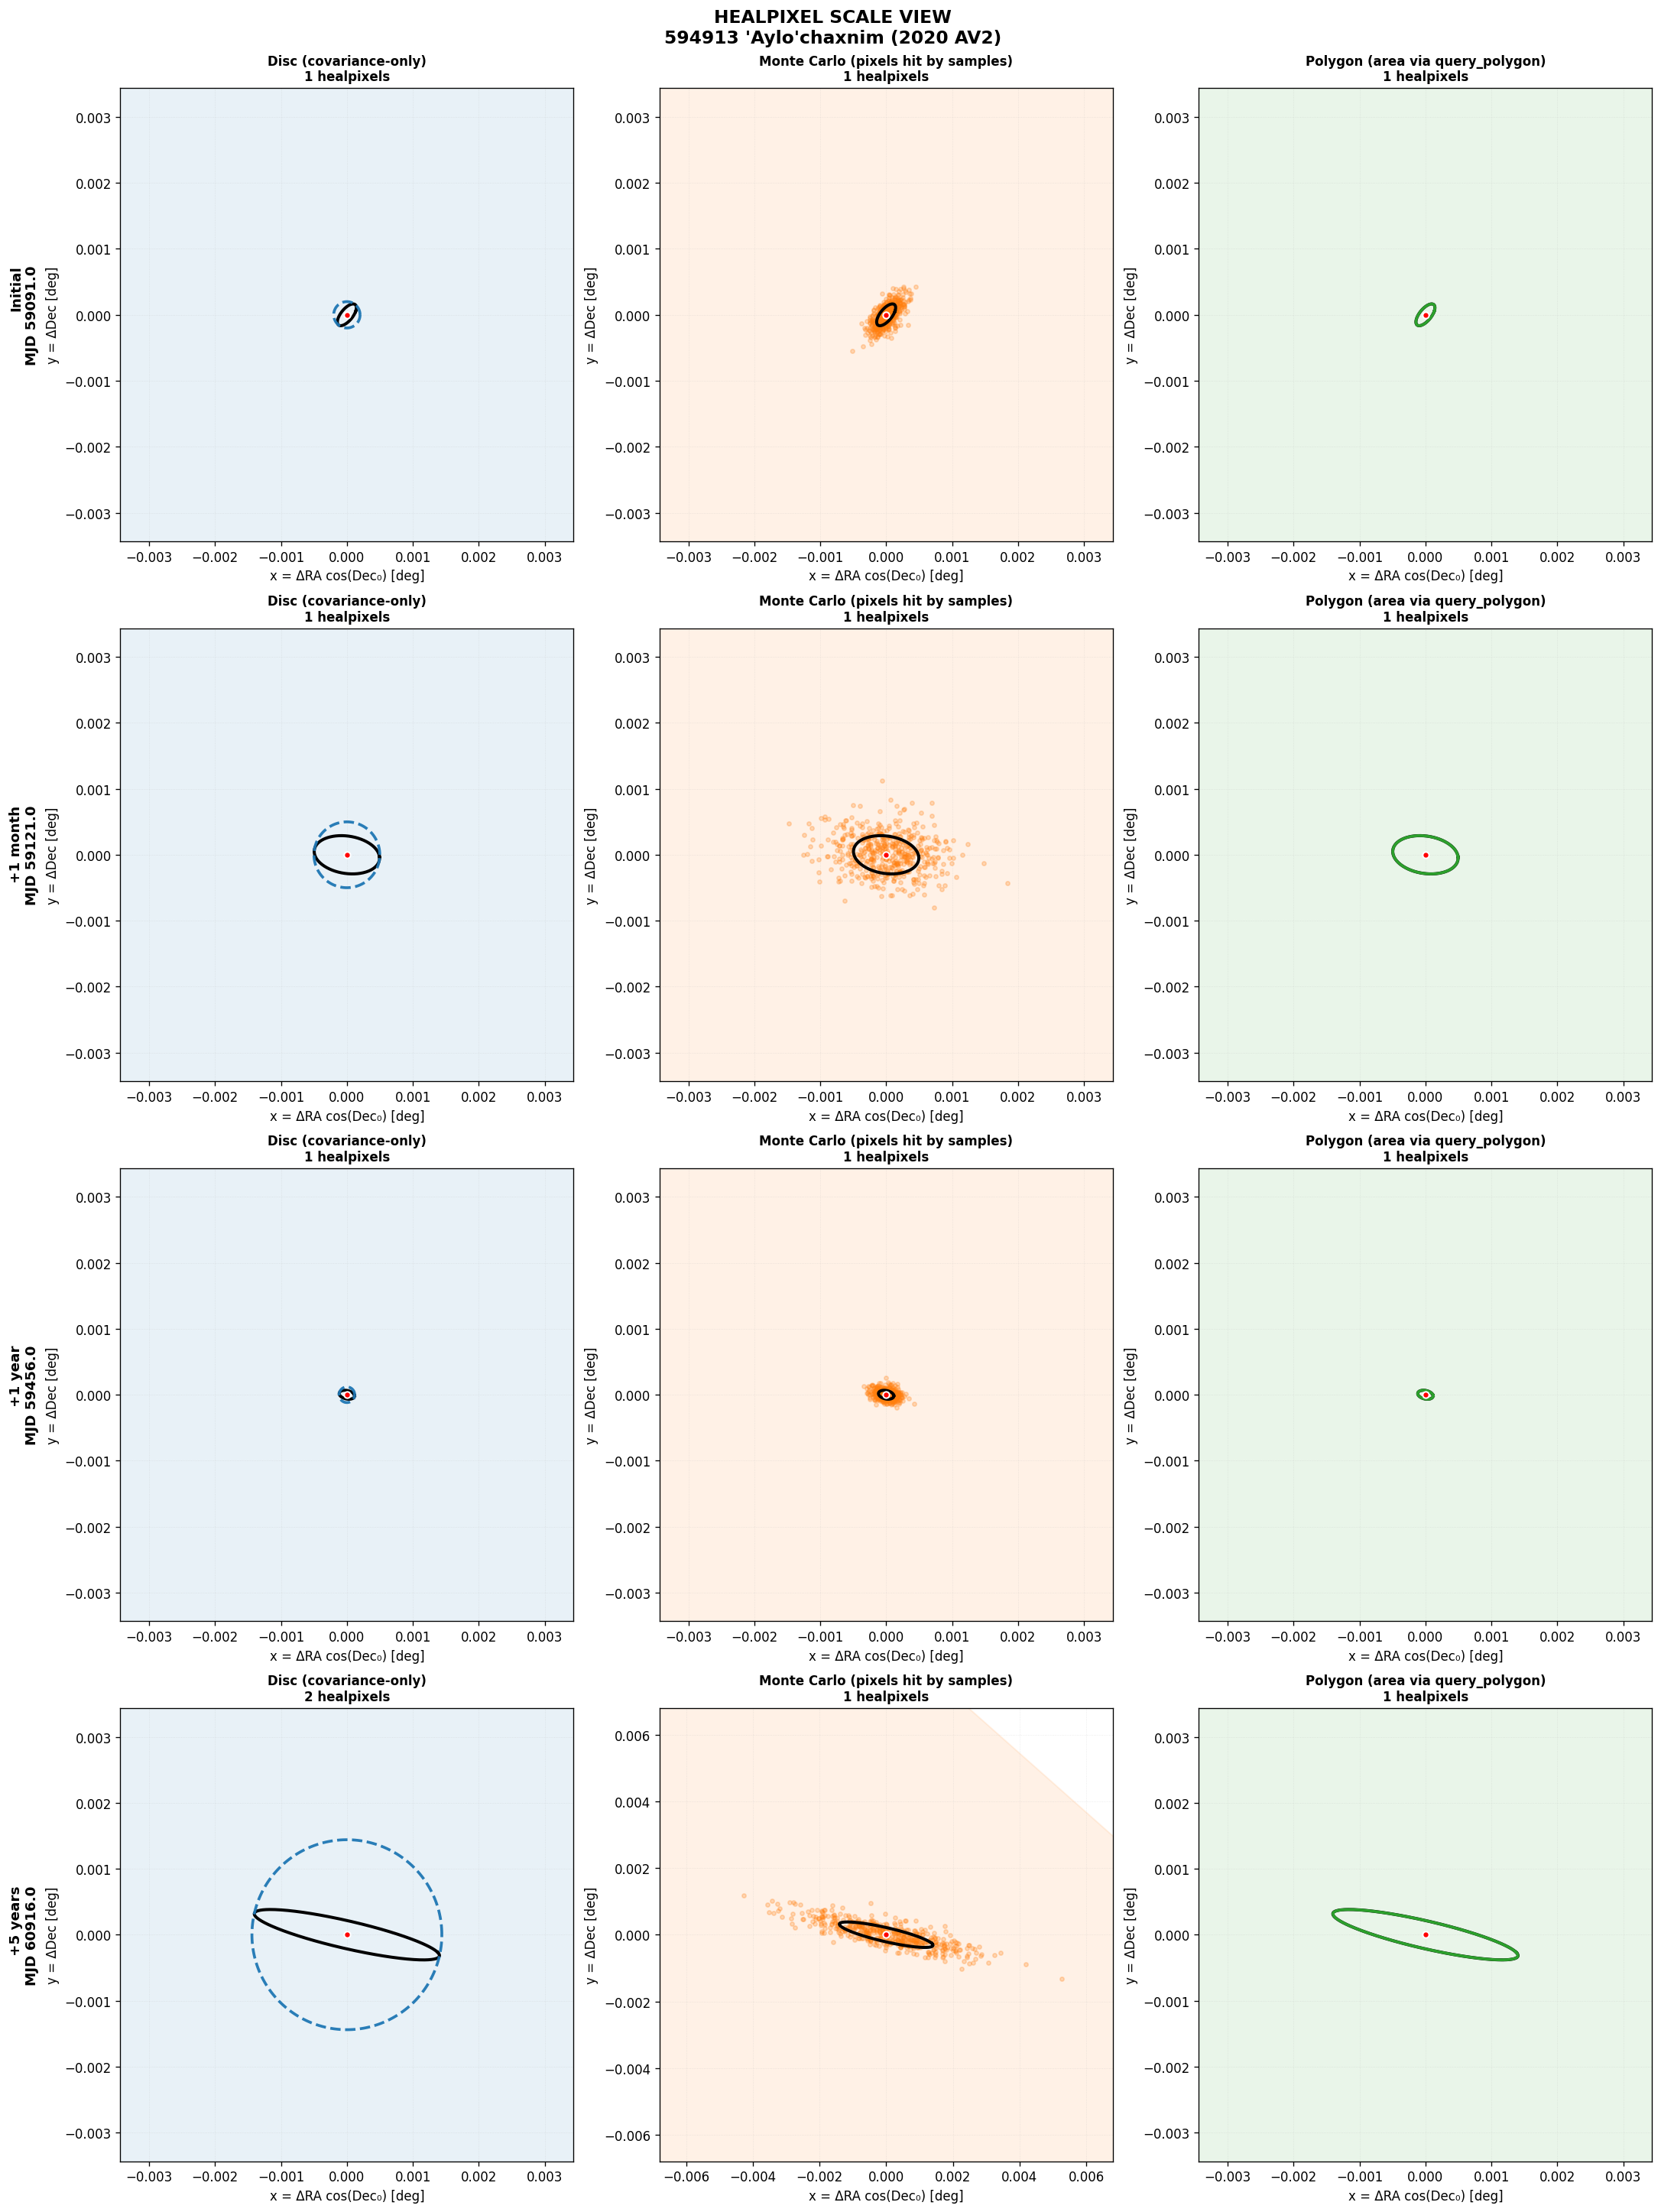


--------------------------------------------------------------------------------
Object 3/6: 15760 Albion (1992 QB1)
mjd, #pix(disc), #pix(mc), #pix(polygon), r_cov(deg)
56220.000      2      1      1   6.794e-05
56250.000      1      1      1   8.360e-05
56585.000      1      1      1   5.634e-05
58045.000      1      1      1   5.991e-05


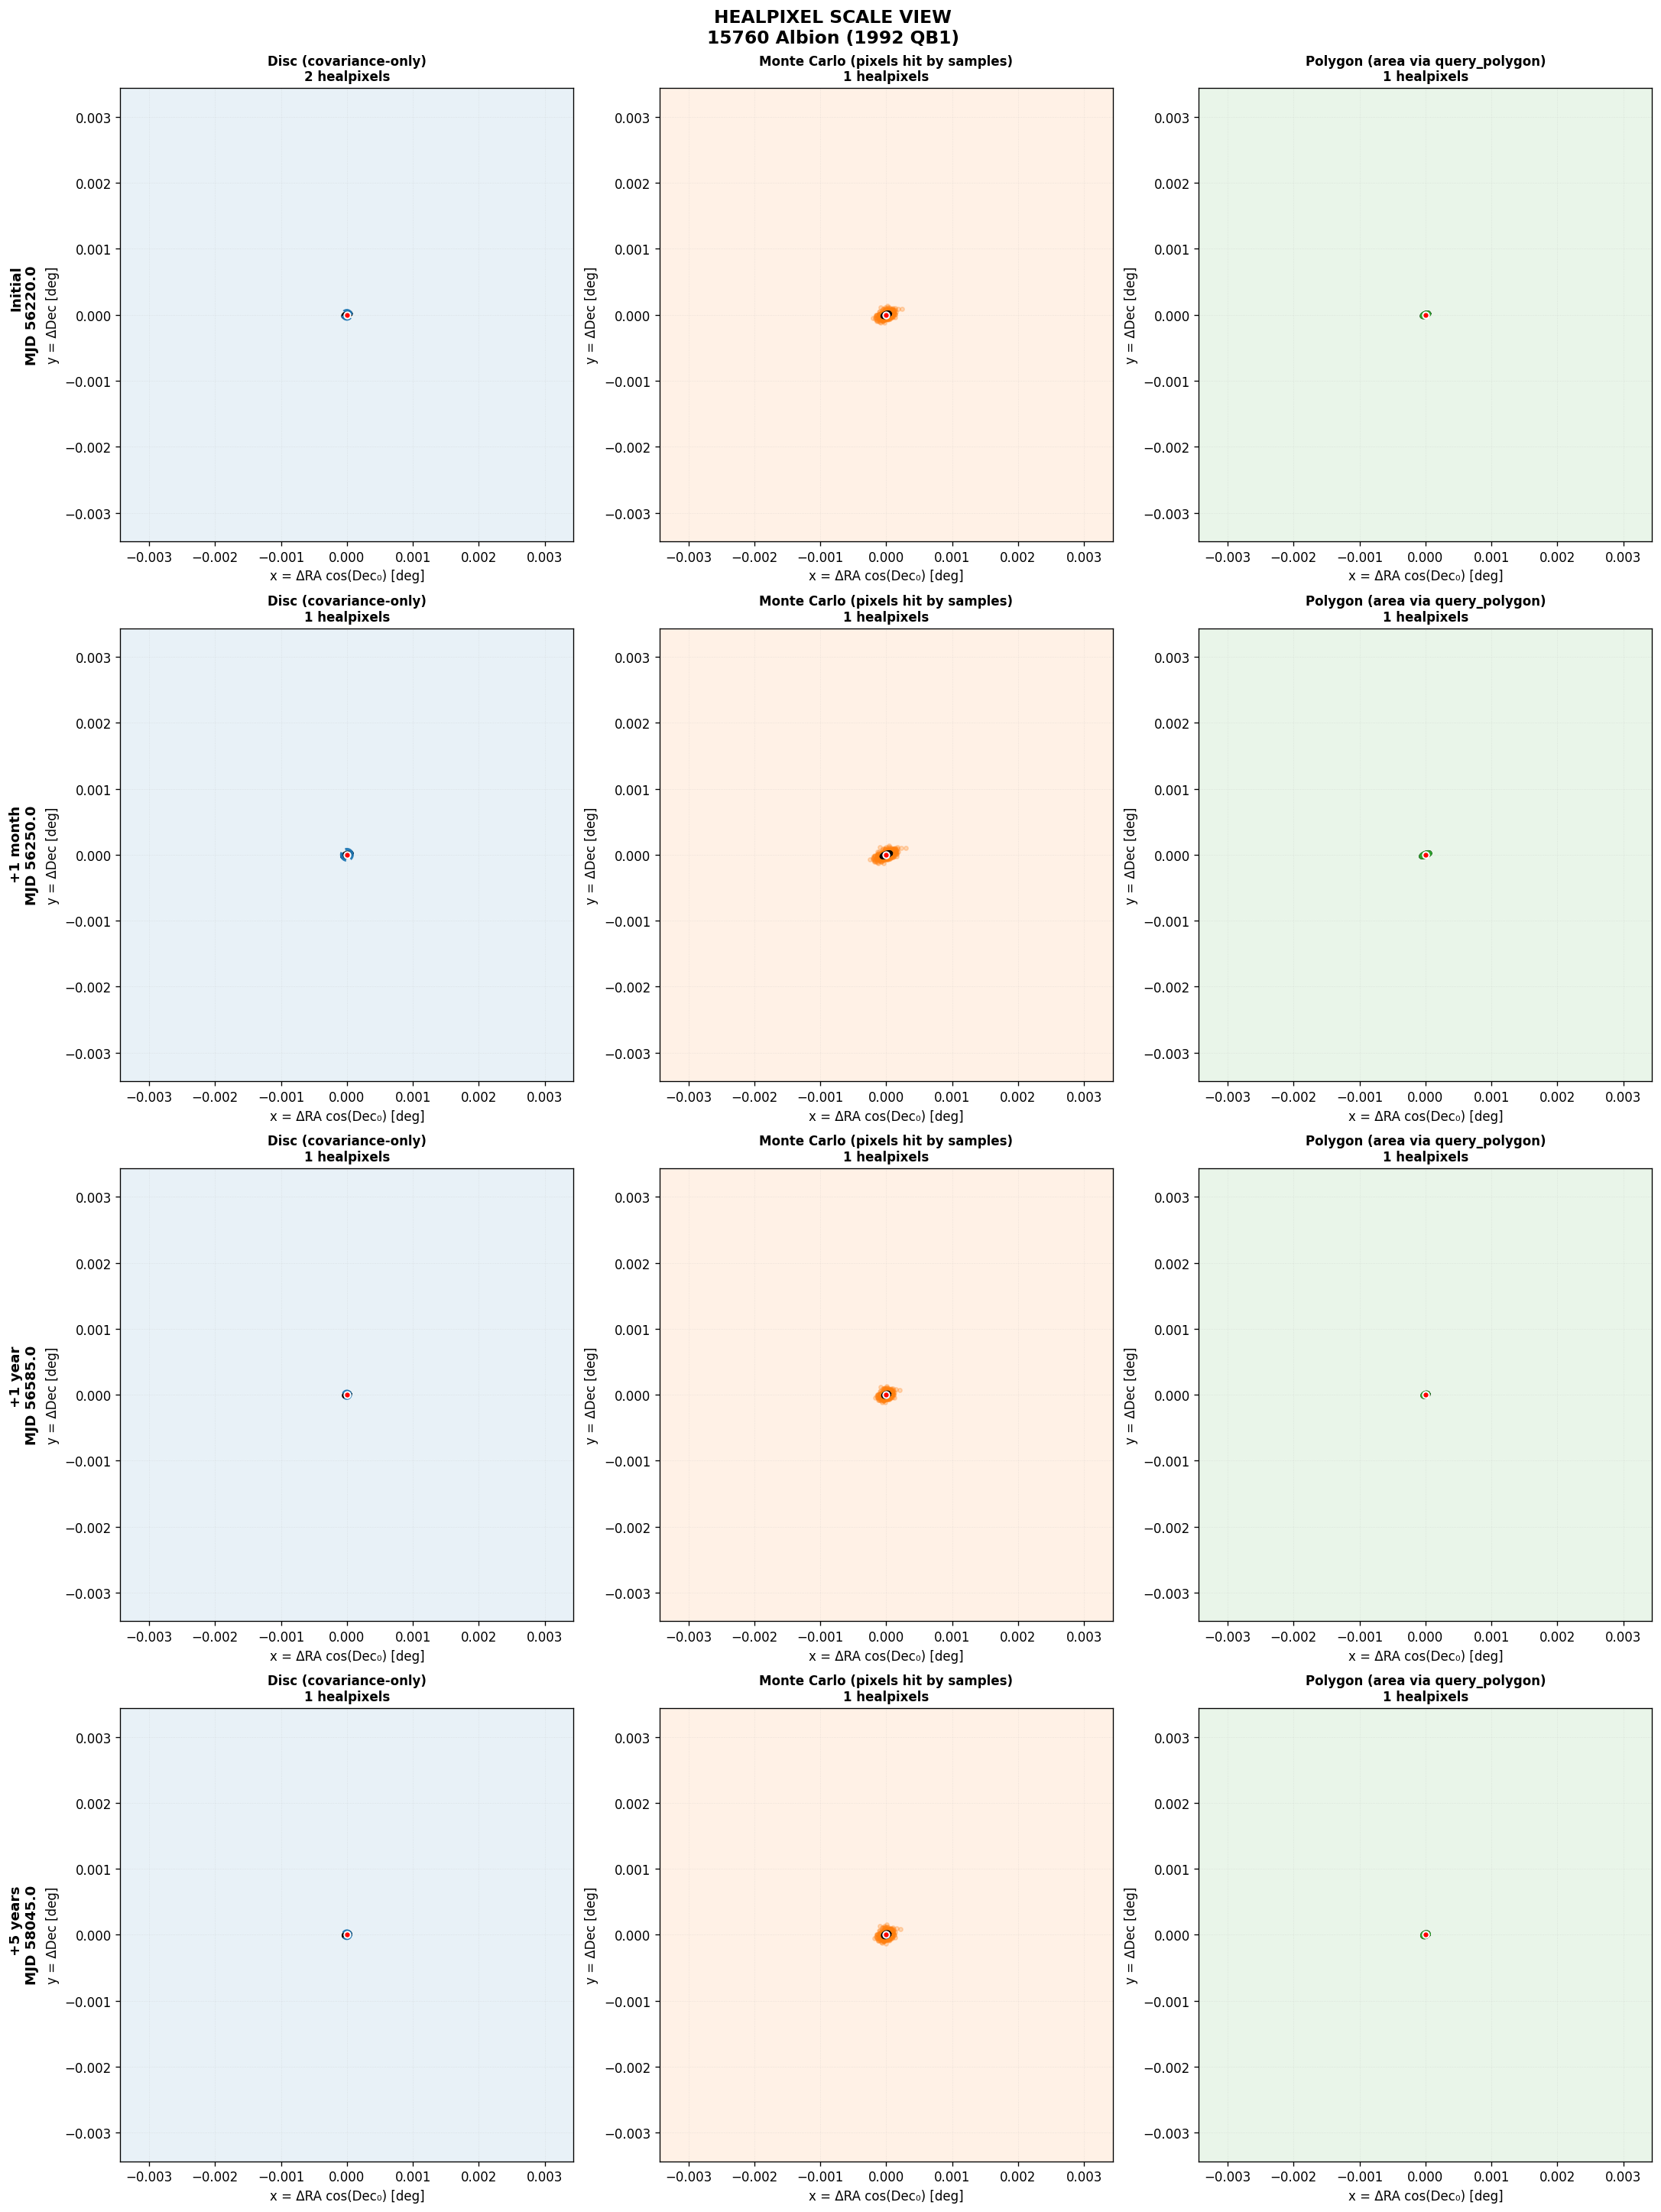


--------------------------------------------------------------------------------
Object 4/6: 15789 (1993 SC)
mjd, #pix(disc), #pix(mc), #pix(polygon), r_cov(deg)
56742.000      1      1      1   3.396e-05
56772.000      1      1      1   2.376e-05
57107.000      1      1      1   3.318e-05
58567.000      2      1      1   3.475e-05


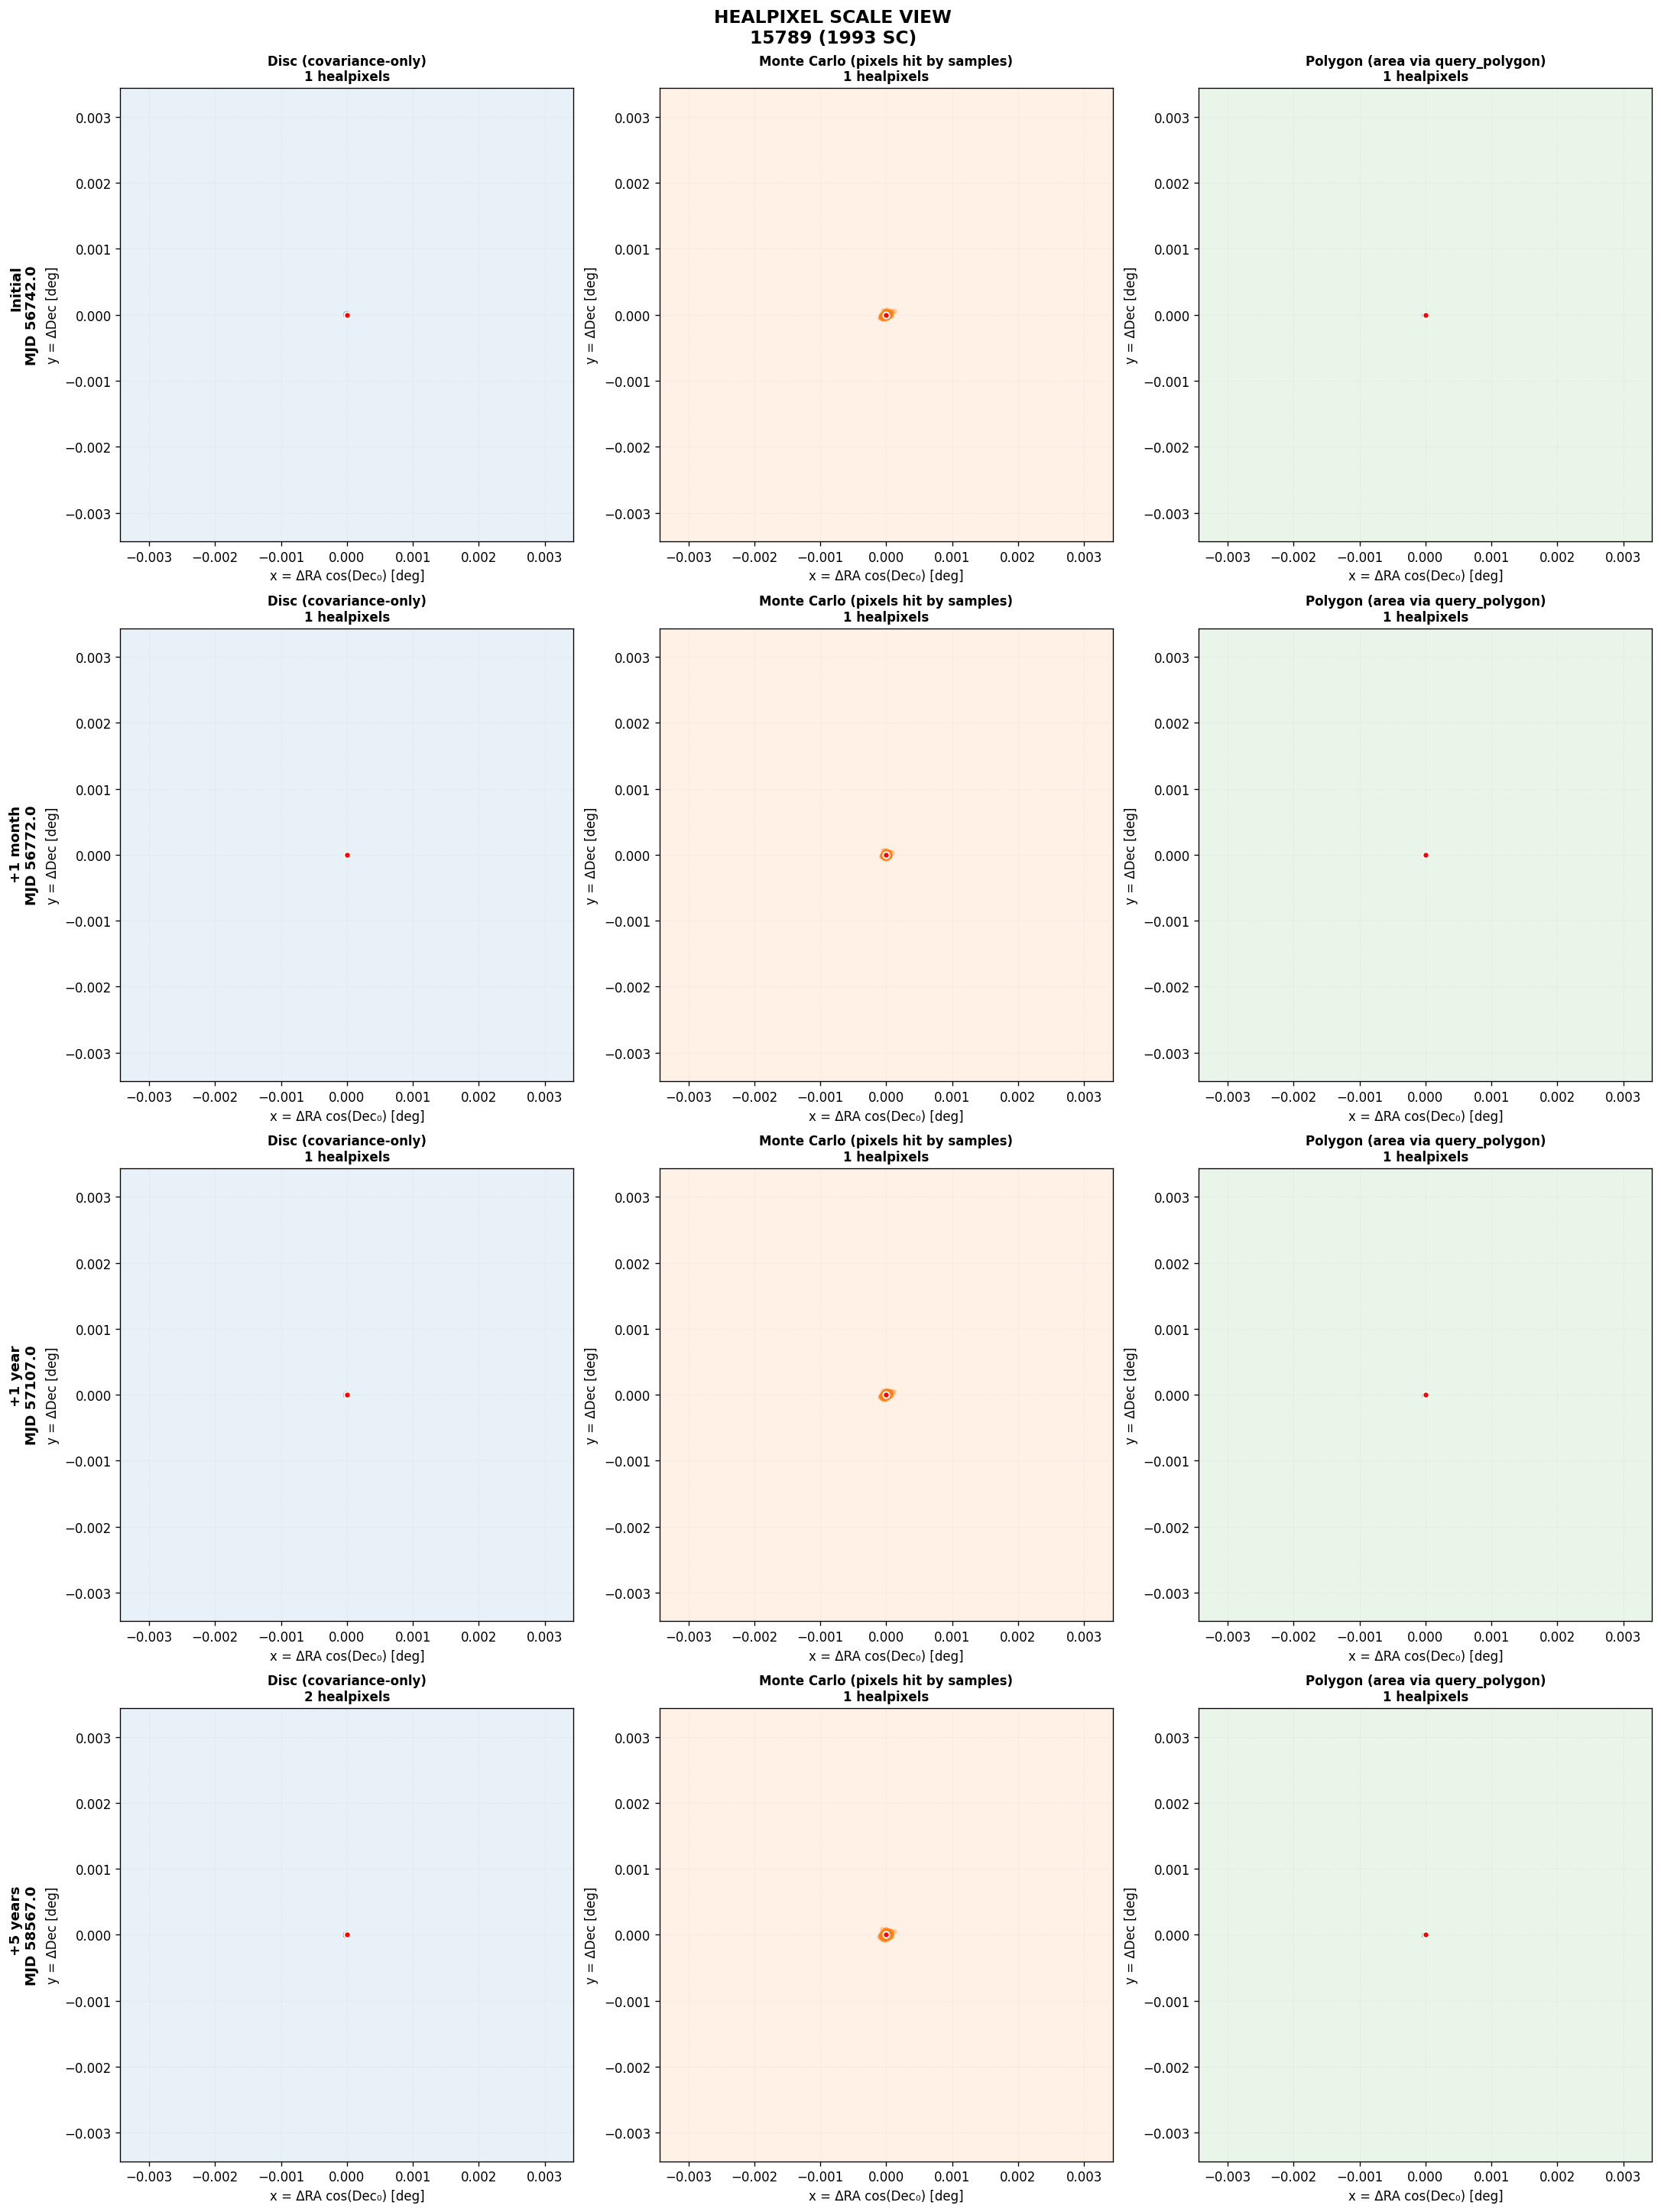


--------------------------------------------------------------------------------
Object 5/6: 202930 Ivezic (1998 SG172)
mjd, #pix(disc), #pix(mc), #pix(polygon), r_cov(deg)
58190.000      1      1      1   2.416e-05
58220.000      1      1      1   2.010e-05
58555.000      2      2      1   2.257e-05
60015.000      2      1      1   2.716e-05


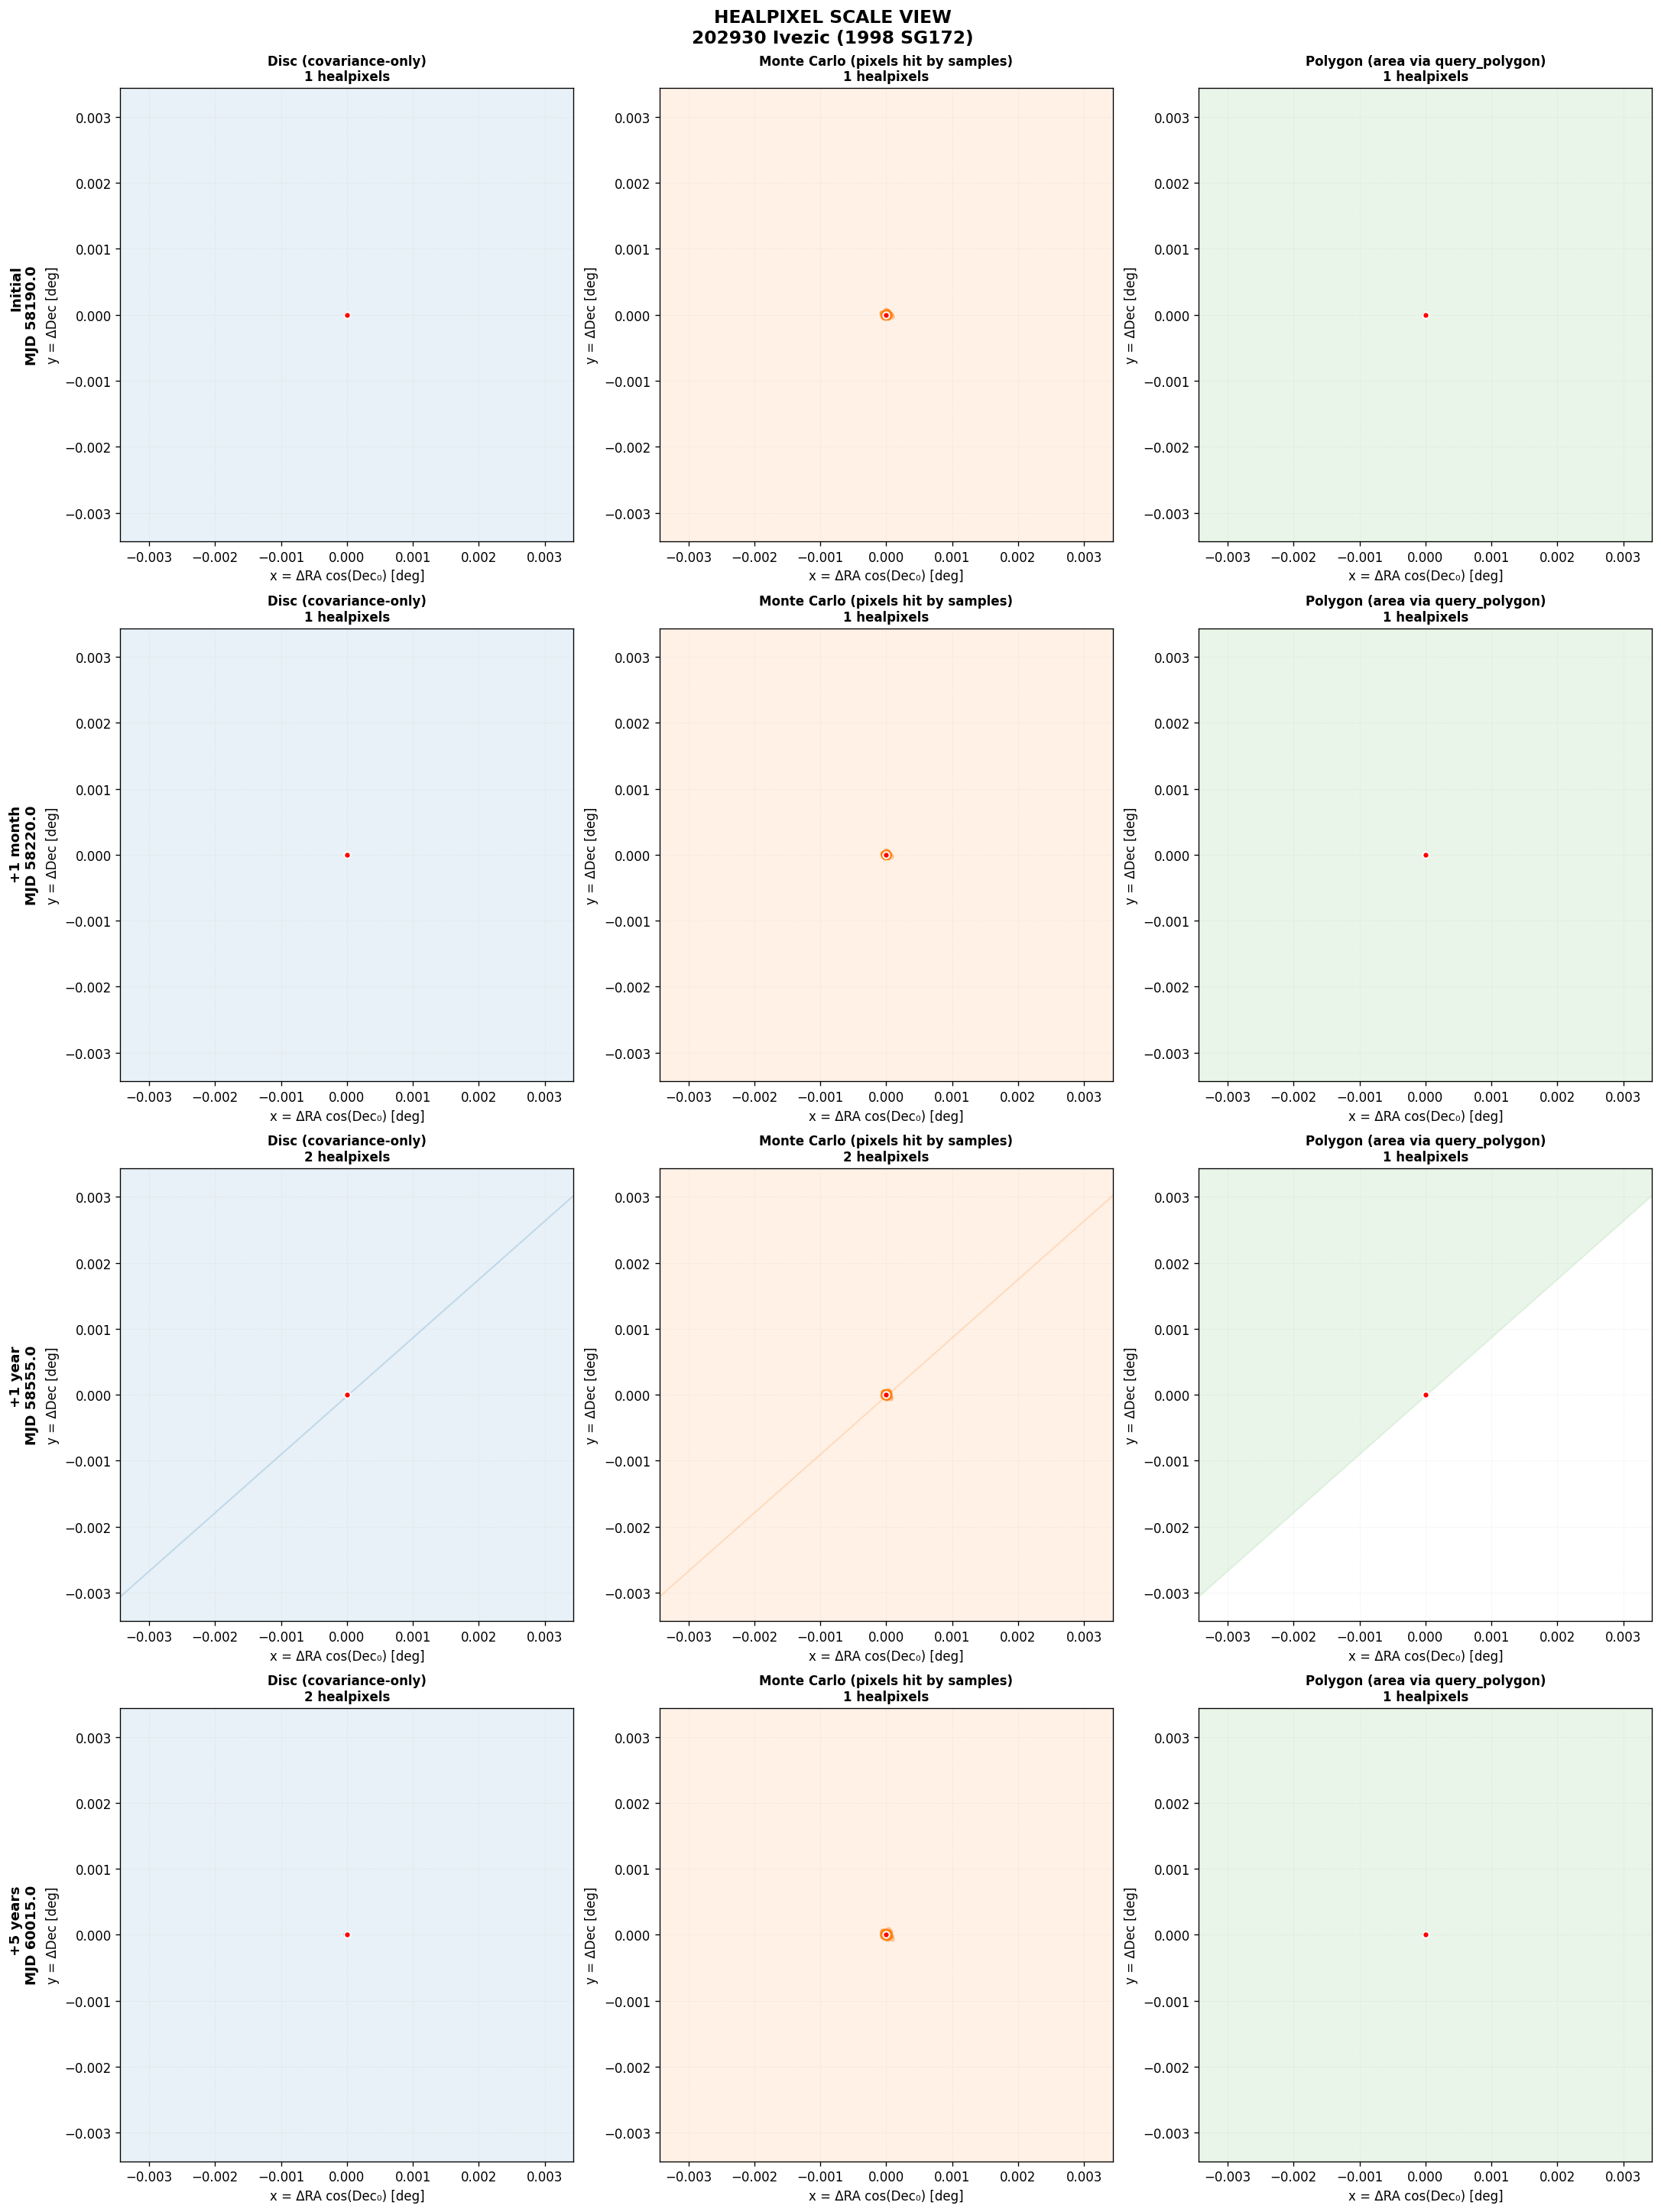


--------------------------------------------------------------------------------
Object 6/6: 2025 MR4


Error encountered at /Users/runner/work/healpy/healpy/cextern/healpix/src/cxx/Healpix_cxx/healpix_base.cc, line 1022
(function void T_Healpix_Base<long long>::query_polygon_internal(const vector<pointing> &, int, rangeset<I2> &) const [I = long long, I2 = long long])

degenerate corner

Error encountered at /Users/runner/work/healpy/healpy/cextern/healpix/src/cxx/Healpix_cxx/healpix_base.cc, line 1022
(function void T_Healpix_Base<long long>::query_polygon_internal(const vector<pointing> &, int, rangeset<I2> &) const [I = long long, I2 = long long])

degenerate corner

Error encountered at /Users/runner/work/healpy/healpy/cextern/healpix/src/cxx/Healpix_cxx/healpix_base.cc, line 1026
(function void T_Healpix_Base<long long>::query_polygon_internal(const vector<pointing> &, int, rangeset<I2> &) const [I = long long, I2 = long long])

polygon is not convex

Error encountered at /Users/runner/work/healpy/healpy/cextern/healpix/src/cxx/Healpix_cxx/healpix_base.cc, line 1026
(function void 

mjd, #pix(disc), #pix(mc), #pix(polygon), r_cov(deg)
60794.000      4      6      3   7.866e-02
60824.000      6      5      2   6.193e-02
61159.000    464     69     29   1.307e+00
62619.000   2318    131     40   3.026e+00


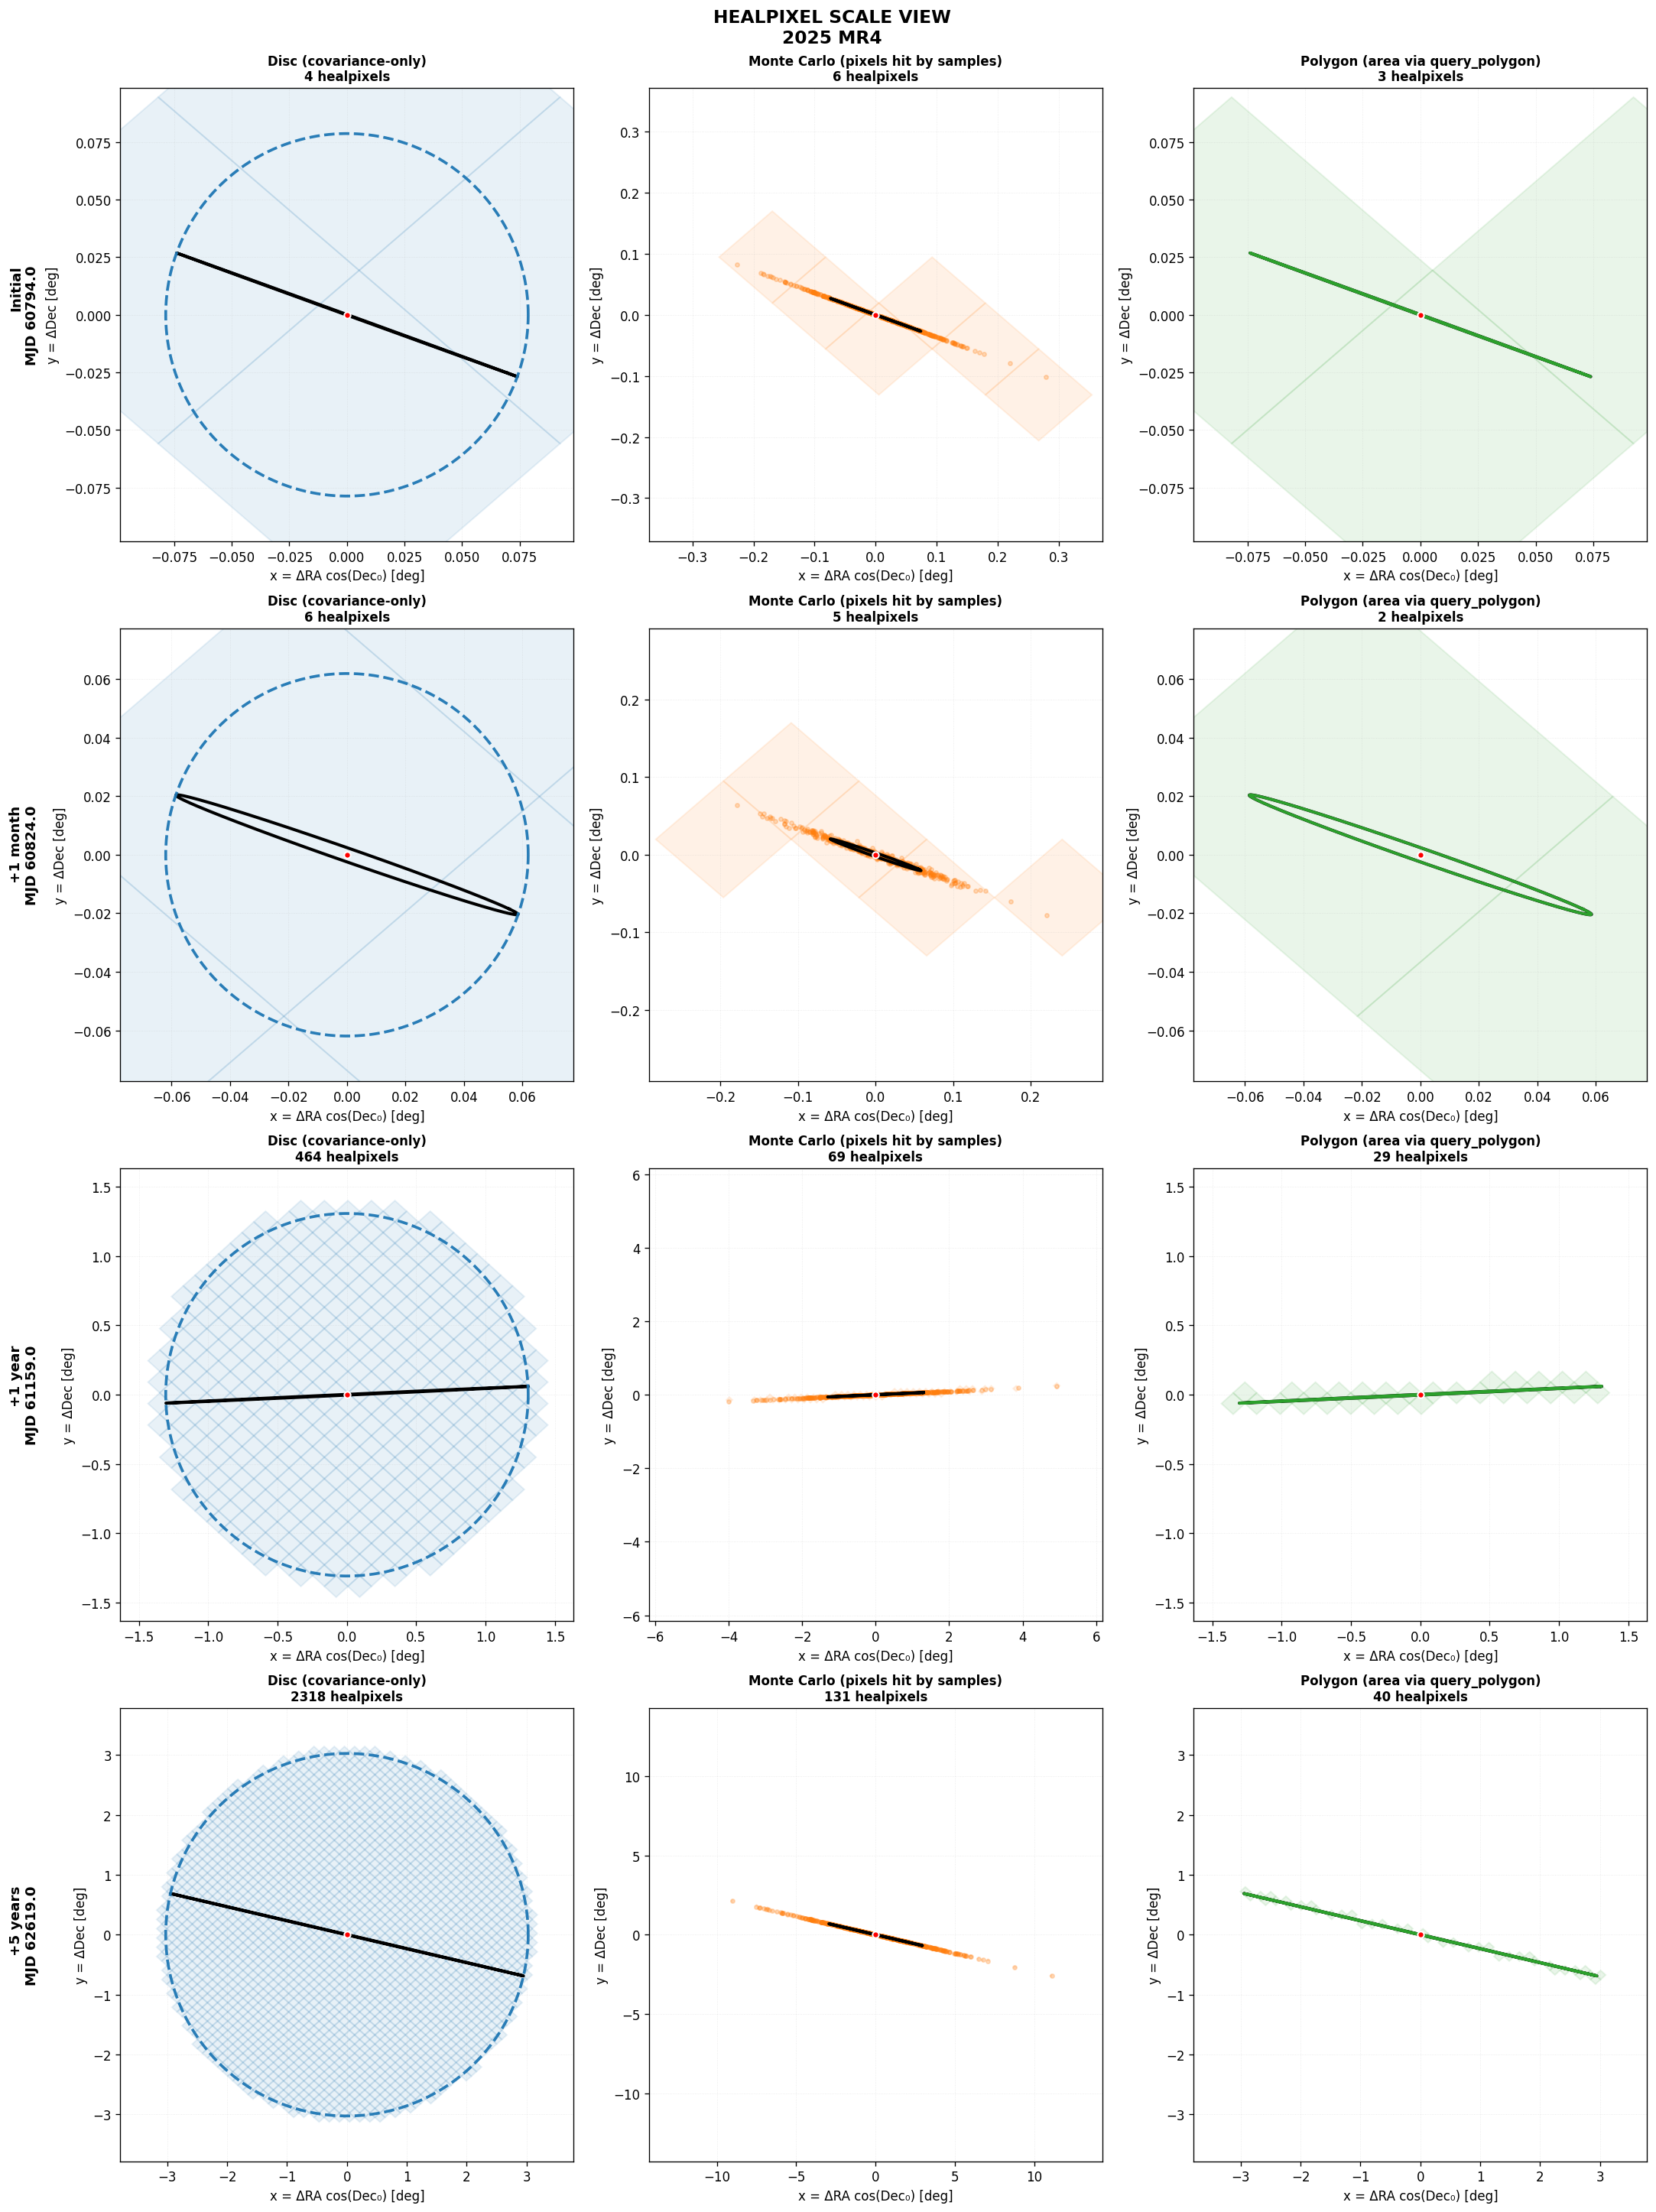


COVARIANCE SCALE VIEW: Showing the physical uncertainty ellipse
NOTE: Zoomed to covariance scale. Healpixels extend far beyond this view.
      Pixel diameter (0.2392°) >> covariance size



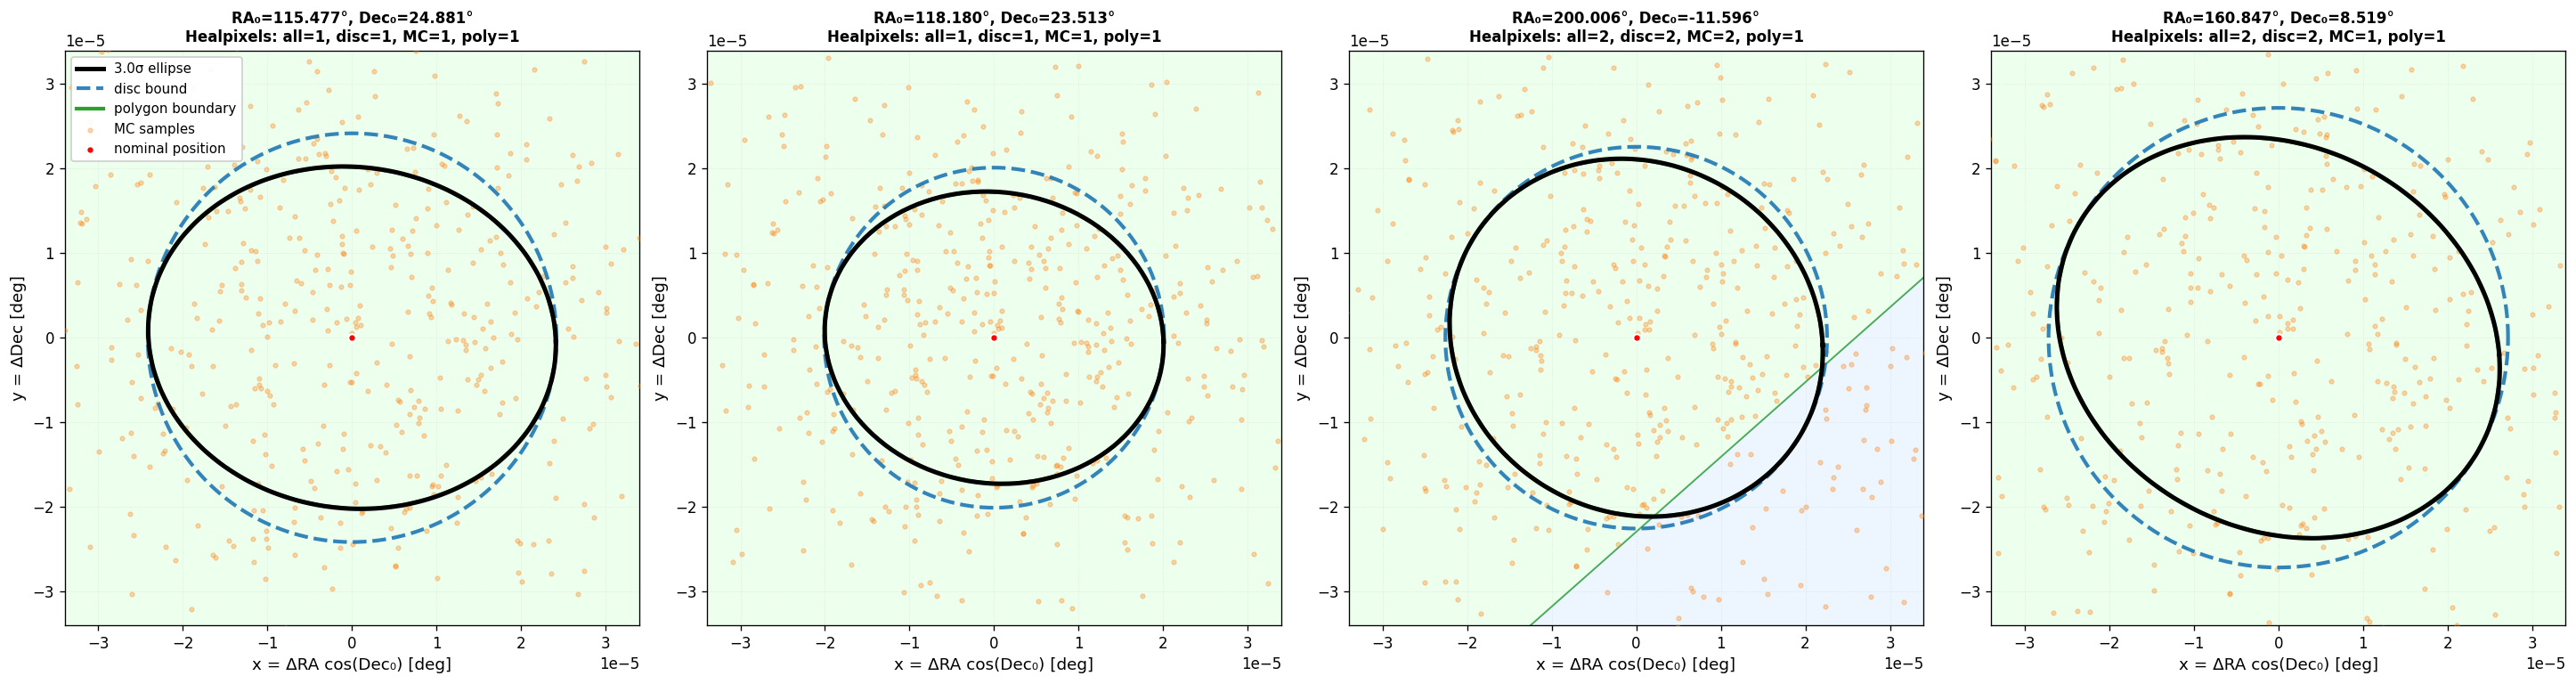

In [28]:
# Run four sample cases: initial, +1 month, +1 year, +5 years
# You can tune these knobs.
nside = 512  # smaller pixels (finer grid)
# Controls how "zoomed in" the healpixel plots are:
# - 5 means ~5 pixels across the full width
# - 3 means bigger pixels (more zoomed in)
healpixels_across = 5

n_sigma = 3.0
poly_vertices = 48
mc_samples = 512
mc_seed = 0

cov6 = eph.coordinates.covariance.to_matrix()

# -----------------------------------------------------------------------------
# MULTI-OBJECT COMPARISON (covariance scale)
# -----------------------------------------------------------------------------
print("=" * 80)
print("MULTI-OBJECT COVARIANCE COMPARISON (tangent-plane 3σ ellipses)")
print("=" * 80)

fig_multi, ax_multi = plt.subplots(1, 4, figsize=(24, 6), constrained_layout=True)
labels = [
    f"{c['orbit'].object_id[0].as_py()}" for c in cases
]
colors = plt.rcParams["axes.prop_cycle"].by_key().get("color", [])

# Plot first, but set a single global axis limit across time panels
global_extent = 0.0
for j, ax in enumerate(ax_multi):
    for k, c in enumerate(cases):
        lat0 = float(c["lat"][j])
        cov_ll = c["cov6"][j, 1:3, 1:3].astype(float)
        cov_xy = cov_lonlat_to_tangent_xy(cov_ll, lat0)
        ell = ellipse_boundary_from_cov(cov_xy, n_sigma=n_sigma, num=256)
        if len(ell):
            global_extent = max(global_extent, float(np.max(np.linalg.norm(ell, axis=1))))
        color = colors[k % len(colors)] if colors else None
        ax.plot(ell[:, 0], ell[:, 1], lw=1.6, color=color, label=labels[k])

global_lim = max(1.25 * global_extent, 1e-6)
for ax in ax_multi:
    ax.set_xlim(-global_lim, global_lim)
    ax.set_ylim(-global_lim, global_lim)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.3, ls=":", lw=0.5)

ax_multi[0].set_title("Initial", fontweight="bold")
ax_multi[1].set_title("+1 month", fontweight="bold")
ax_multi[2].set_title("+1 year", fontweight="bold")
ax_multi[3].set_title("+5 years", fontweight="bold")
ax_multi[0].set_xlabel("x = ΔRA cos(Dec₀) [deg]")
ax_multi[0].set_ylabel("y = ΔDec [deg]")
ax_multi[0].legend(loc="best", fontsize=7, framealpha=0.95)
plt.show()

# -----------------------------------------------------------------------------
# PER-OBJECT VIEW (healpixels)
# -----------------------------------------------------------------------------
print("=" * 80)
print("HEALPIXEL SCALE VIEW: Showing which healpixels are selected")
print("=" * 80)
print(f"HEALPix nside={nside} → pixel diameter ≈ {2*np.rad2deg(hp.max_pixrad(nside)):.4f}°\n")
print(f"Objects plotted: {len(cases)}")

time_labels = ["Initial", "+1 month", "+1 year", "+5 years"]

for case_i, c in enumerate(cases):
    orbit_i = c["orbit"]
    object_id_i = orbit_i.object_id[0].as_py()
    mjds_i = c["mjds"]
    eph_i = c["eph"]
    cov6_i = c["cov6"]

    print("\n" + "-" * 80)
    print(f"Object {case_i+1}/{len(cases)}: {object_id_i}")

    fig0, axes0 = plt.subplots(4, 3, figsize=(18, 24), constrained_layout=True)
    fig0.suptitle(f"HEALPIXEL SCALE VIEW\n{object_id_i}", fontsize=14, fontweight="bold")

    summary = []
    for t_i in range(4):
        lon0 = float(eph_i.coordinates.lon[t_i].as_py())
        lat0 = float(eph_i.coordinates.lat[t_i].as_py())
        cov_ll = cov6_i[t_i, 1:3, 1:3].astype(float)

        disc_set, mc_set, poly_set, r_cov_deg = plot_case_separated(
            axes0[t_i],
            lon0,
            lat0,
            cov_ll,
            nside=nside,
            n_sigma=n_sigma,
            num_vertices=poly_vertices,
            mc_samples=mc_samples,
            mc_seed=mc_seed,
            pixels_across=healpixels_across,
        )
        summary.append((float(mjds_i[t_i]), len(disc_set), len(mc_set), len(poly_set), float(r_cov_deg)))

        axes0[t_i, 0].text(
            -0.18,
            0.5,
            f"{time_labels[t_i]}\nMJD {float(mjds_i[t_i]):.1f}",
            transform=axes0[t_i, 0].transAxes,
            fontsize=11,
            fontweight="bold",
            rotation=90,
            va="center",
            ha="right",
        )

    print("mjd, #pix(disc), #pix(mc), #pix(polygon), r_cov(deg)")
    for mjd, disc_n, mc_n, poly_n, r_cov in summary:
        print(f"{mjd:.3f}  {disc_n:5d}  {mc_n:5d}  {poly_n:5d}   {r_cov:.3e}")

    plt.show()

print("\n" + "=" * 80)
print("COVARIANCE SCALE VIEW: Showing the physical uncertainty ellipse")
print("=" * 80)
print("NOTE: Zoomed to covariance scale. Healpixels extend far beyond this view.")
print(f"      Pixel diameter ({2*np.rad2deg(hp.max_pixrad(nside)):.4f}°) >> covariance size\n")

fig1, axes1 = plt.subplots(1, 4, figsize=(24, 6), constrained_layout=True)

# Precompute a global lim so the covariance-scale panels share the same x/y axes
extents = []
for i in range(4):
    lon0 = float(eph.coordinates.lon[i].as_py())
    lat0 = float(eph.coordinates.lat[i].as_py())
    cov_ll = cov6[i, 1:3, 1:3].astype(float)
    cov_xy = cov_lonlat_to_tangent_xy(cov_ll, lat0)
    ell = ellipse_boundary_from_cov(cov_xy, n_sigma=n_sigma, num=256)
    _, r_cov_rad = disc_pixels(lon0, lat0, cov_ll, nside, n_sigma=n_sigma)
    r_cov_deg = float(np.rad2deg(r_cov_rad))
    e = float(np.max(np.linalg.norm(ell, axis=1))) if len(ell) else 0.0
    extents.append(max(e, r_cov_deg))

global_lim = max(1.25 * float(np.max(extents)), 1e-6)

for i, ax in enumerate(axes1):
    lon0 = float(eph.coordinates.lon[i].as_py())
    lat0 = float(eph.coordinates.lat[i].as_py())
    cov_ll = cov6[i, 1:3, 1:3].astype(float)

    plot_case(
        ax,
        lon0,
        lat0,
        cov_ll,
        nside=nside,
        n_sigma=n_sigma,
        num_vertices=poly_vertices,
        mc_samples=mc_samples,
        mc_seed=mc_seed,
    )

    ax.set_xlim(-global_lim, global_lim)
    ax.set_ylim(-global_lim, global_lim)

axes1[0].legend(loc="best", fontsize=9, framealpha=0.95)
plt.show()

In [ ]:
# -----------------------------------------------------------------------------
# Timing / performance comparison of healpixel selection methods
# -----------------------------------------------------------------------------
from time import perf_counter

print("\n" + "=" * 80)
print("TIMING: healpixel selection methods")
print("=" * 80)

# Configure the benchmark
bench_nside = nside
bench_n_sigma = n_sigma
bench_poly_vertices = poly_vertices
bench_mc_samples = mc_samples
bench_mc_seed = mc_seed

# How many ephemeris time steps per object to test.
# Keep this moderate; the selection methods are fast but polygon can be heavier.
bench_num_steps = 200
bench_span_days = 5.0 * 365.0

# Pick a few objects from the local test set (avoid SBDB/network dependencies)
# You can edit this list freely.
bench_object_ids = [
    "5335 Damocles (1991 DA)",
    "594913 'Aylo'chaxnim (2020 AV2)",
    "202930 Ivezic (1998 SG172)",
]

bench_orbits = []
for oid in bench_object_ids:
    try:
        bench_orbits.append(orbits.select("object_id", oid))
    except Exception:
        print(f"(benchmark) object_id not found in current `orbits`: {oid!r}")

if not bench_orbits:
    raise RuntimeError("No benchmark orbits selected/found.")

print(f"Benchmark objects: {len(bench_orbits)}")
print(f"Time steps per object: {bench_num_steps} over {bench_span_days:.1f} days")
print(f"nside={bench_nside}, n_sigma={bench_n_sigma}, mc_samples={bench_mc_samples}, poly_vertices={bench_poly_vertices}\n")

# Build ephemerides (dominant cost). We time selection separately below.
bench_ephems = []
for orb in bench_orbits:
    epoch_mjd = float(orb.coordinates.time.mjd().to_numpy(zero_copy_only=False)[0])
    mjds_b = np.linspace(epoch_mjd, epoch_mjd + bench_span_days, int(bench_num_steps), dtype=float)
    times_b = orb.coordinates.time.from_mjd(mjds_b, scale="utc")

    mean_time = orb.coordinates.time.from_mjd([float(mjds_b.mean())], scale="utc")
    mean_orb = prop.propagate_orbits(orb, mean_time, covariance=True)
    propagated = propagate_2body(mean_orb, times_b)
    observers_b = Observers.from_code(obscode, times_b)
    eph_b = generate_ephemeris_2body(propagated, observers_b)

    cov6_b = eph_b.coordinates.covariance.to_matrix()
    lon_b = eph_b.coordinates.lon.to_numpy(zero_copy_only=False).astype(float)
    lat_b = eph_b.coordinates.lat.to_numpy(zero_copy_only=False).astype(float)

    bench_ephems.append((orb.object_id[0].as_py(), mjds_b, lon_b, lat_b, cov6_b))

# Helper: time a callable that runs one method across all (object, step)
def time_method(label, fn):
    # Warm-up
    fn()
    t0 = perf_counter()
    fn()
    dt = perf_counter() - t0
    return dt

# Build method runners
n_calls = len(bench_ephems) * int(bench_num_steps)


def run_disc():
    for _, _, lon_b, lat_b, cov6_b in bench_ephems:
        for i in range(int(bench_num_steps)):
            cov_ll = cov6_b[i, 1:3, 1:3].astype(float)
            disc_pixels(float(lon_b[i]), float(lat_b[i]), cov_ll, bench_nside, n_sigma=bench_n_sigma)


def run_mc():
    for _, _, lon_b, lat_b, cov6_b in bench_ephems:
        for i in range(int(bench_num_steps)):
            cov_ll = cov6_b[i, 1:3, 1:3].astype(float)
            mc_pixels(
                float(lon_b[i]),
                float(lat_b[i]),
                cov_ll,
                bench_nside,
                n_sigma=bench_n_sigma,
                num_samples=int(bench_mc_samples),
                seed=int(bench_mc_seed),
            )


def run_polygon():
    for _, _, lon_b, lat_b, cov6_b in bench_ephems:
        for i in range(int(bench_num_steps)):
            cov_ll = cov6_b[i, 1:3, 1:3].astype(float)
            polygon_pixels(
                float(lon_b[i]),
                float(lat_b[i]),
                cov_ll,
                bench_nside,
                n_sigma=bench_n_sigma,
                num_vertices=int(bench_poly_vertices),
            )


dt_disc = time_method("disc", run_disc)
dt_mc = time_method("mc", run_mc)
dt_poly = time_method("polygon", run_polygon)

print("\nMethod timing (selection only; ephemeris precomputed):")
print(f"  disc:    {dt_disc:8.3f} s  ({1e3 * dt_disc / n_calls:8.3f} ms/call)  calls={n_calls}")
print(f"  mc:      {dt_mc:8.3f} s  ({1e3 * dt_mc / n_calls:8.3f} ms/call)  calls={n_calls}")
print(f"  polygon: {dt_poly:8.3f} s  ({1e3 * dt_poly / n_calls:8.3f} ms/call)  calls={n_calls}")

print("\nNotes:")
print("- This compares healpixel-selection compute only (disc/mc/polygon) using the same precomputed ephemerides.")
print("- If you want end-to-end timings (propagation + selection), we can add that too.")



TIMING: healpixel selection methods
Benchmark objects: 3
Time steps per object: 200 over 1825.0 days
nside=512, n_sigma=3.0, mc_samples=512, poly_vertices=48


Method timing (selection only; ephemeris precomputed):
  disc:       0.015 s  (   0.025 ms/call)  calls=600
  mc:         0.060 s  (   0.099 ms/call)  calls=600
  polygon:    0.023 s  (   0.038 ms/call)  calls=600

Notes:
- This compares healpixel-selection compute only (disc/mc/polygon) using the same precomputed ephemerides.
- If you want end-to-end timings (propagation + selection), we can add that too.
